<a href="https://colab.research.google.com/github/DhimanTarafdar/BBB/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔷 Need for Transformer Model (Transformer কেন প্রয়োজন হলো?)

## 1️⃣ প্রেক্ষাপট: Sequence Modeling-এর যাত্রা

ভাষা বা যেকোনো sequential data (text, speech, time-series) প্রসেস করার জন্য প্রথমে ব্যবহার হতো:

**RNN → LSTM → GRU → (Attention + RNN) → Transformer**

প্রতিটি ধাপে আগের মডেলের সমস্যা সমাধানের চেষ্টা হয়েছে, কিন্তু পুরোপুরি সমাধান হয়েছে **Transformer** দিয়েই।

---

## 2️⃣ কেন RNN/LSTM যথেষ্ট ছিল না? (মূল কারণ)

### 🔴 Reason 1: No Parallelization (Sequential Bottleneck)
RNN-এর computation নিচের মতো:

$$h_t = f(h_{t-1}, x_t)$$

অর্থাৎ, $h_t$ বের করতে হলে অবশ্যই $h_{t-1}$ আগে বের করতে হবে। এই **dependency chain**-এর কারণে:
- GPU-এর parallel computation power কাজে লাগানো যেত না
- বড় dataset-এ training করতে **সপ্তাহ-মাস** সময় লাগতো

### 🔴 Reason 2: Long-Range Dependency সমস্যা
Sentence-এর দূরত্ব বেশি হলে RNN তথ্য "মনে রাখতে" পারতো না (vanishing/exploding gradient)।
- Theoretical ভাবে LSTM এটা কিছুটা কমিয়েছিল (gating mechanism দিয়ে), কিন্তু খুব লম্বা sequence-এ (৫০+ word) এখনো সমস্যা থেকেই যেত

### 🔴 Reason 3: Information Bottleneck (Encoder-Decoder Architecture-এ)
পুরনো Seq2Seq মডেলে:
- Encoder পুরো input sentence-কে একটা **single fixed-size vector**-এ compress করতো
- Decoder শুধু সেই একটা vector থেকেই পুরো output generate করতো

→ ফলে বড় sentence-এর প্রথম দিকের তথ্য প্রায়ই হারিয়ে যেত (bottleneck problem)

### 🔴 Reason 4: Attention যোগ হলেও গতি সমস্যা থেকে যায়
২০১৪-১৫ সালে **Bahdanau/Luong Attention** যোগ করা হয় RNN-এর সাথে, যা context বোঝার সমস্যা কিছুটা কমায়— কিন্তু RNN-এর **sequential নেচার** এখনো থেকে যাওয়ায় training speed-এর সমস্যা রয়েই যায়।

---

## 3️⃣ তাহলে ঠিক কী দরকার ছিল? (The Need)

একটা এমন architecture দরকার ছিল যেটা:

| প্রয়োজন | ব্যাখ্যা |
|---|---|
| **Parallel Processing** | সব token একসাথে প্রসেস হবে, এক এক করে না |
| **Full Context Access** | প্রতিটি word সরাসরি sentence-এর **সব** word-এর সাথে সম্পর্ক তৈরি করতে পারবে, distance যাই হোক |
| **Scalability** | Model ও data বড় করলে performance আরও ভালো হবে (deep + wide scaling সম্ভব হবে) |
| **No Information Bottleneck** | পুরো sentence-এর তথ্য একটামাত্র vector-এ compress না করে, প্রতিটি token-এর জন্য আলাদা attention distribution থাকবে |

---

## 4️⃣ Transformer কীভাবে এই Need পূরণ করলো?

**২০১৭ সালে "Attention Is All You Need"** পেপারে বলা হয় — RNN/CNN একেবারেই বাদ দিয়ে শুধুমাত্র **Self-Attention mechanism** দিয়েই sequence modeling সম্ভব।

- 🔹 **Self-Attention** → প্রতিটি token একসাথে (parallel-ly) বাকি সব token-এর সাথে সম্পর্ক হিসাব করে
- 🔹 **Positional Encoding** → parallel প্রসেসিং-এ word-এর ক্রম (order) বজায় রাখার জন্য
- 🔹 **Multi-Head Attention** → sentence-এর বিভিন্ন ধরনের সম্পর্ক (syntactic, semantic) একসাথে ধরতে পারে

---

## 📌 সংক্ষেপে (Summary)

> Transformer-এর প্রয়োজন হয়েছিল কারণ RNN/LSTM ছিল **ধীরগতির (sequential)**, **long-range dependency** ধরতে দুর্বল, এবং **information bottleneck**-এ ভুগতো। Transformer এই তিনটা সমস্যাই একসাথে সমাধান করেছে **Self-Attention + Parallelization**-এর মাধ্যমে, যা একে দ্রুত, শক্তিশালী এবং বড় স্কেলে training-উপযোগী করে তুলেছে — যা আজকের GPT, BERT-এর মতো মডেলের ভিত্তি।

# 🔷 Transformer কী এবং কেন প্রয়োজন হলো?

## 1️⃣ Transformer কী?

**Transformer** হলো একটি deep learning architecture, যা ২০১৭ সালে Google-এর গবেষকরা **"Attention Is All You Need"** পেপারে প্রকাশ করেন। এটি মূলত ডিজাইন করা হয়েছিল **sequential data** (যেমন: টেক্সট, ভাষা) প্রসেস করার জন্য, কিন্তু এখন এটি ছবি, অডিও, ভিডিও — সবখানেই ব্যবহৃত হয়।

Transformer-এর মূল বৈশিষ্ট্য হলো এটি **"Self-Attention" mechanism** ব্যবহার করে একটি sequence-এর সব word/token-কে **একসাথে (parallel-ly)** প্রসেস করতে পারে — RNN/LSTM-এর মতো এক এক করে (sequentially) নয়।

---

## 2️⃣ Transformer আসার আগে কী সমস্যা ছিল? (RNN/LSTM এর Problem)

Transformer আসার আগে NLP-তে মূলত **RNN (Recurrent Neural Network)** এবং তার উন্নত ভার্সন **LSTM / GRU** ব্যবহার হতো। এদের সমস্যাগুলো ছিল:

### ❌ Problem 1: Sequential Processing (ধীর গতি)
RNN একটা sentence-এর word গুলো **এক এক করে, ক্রমানুসারে** প্রসেস করে। মানে ৫ম word প্রসেস করতে হলে আগে ১ম, ২য়, ৩য়, ৪র্থ word প্রসেস শেষ হতে হবে।
- এর ফলে **parallelization** (একসাথে সব প্রসেস করা) সম্ভব হতো না
- Training এবং inference **অনেক slow** হতো, বিশেষ করে বড় dataset-এ

### ❌ Problem 2: Long-Range Dependency / Vanishing Gradient
Sentence যদি বড় হয় (যেমন ৫০-১০০ word), তাহলে শুরুর দিকের word-এর তথ্য শেষ পর্যন্ত পৌঁছাতে পৌঁছাতে **হারিয়ে যেতো** (vanishing gradient problem)।
- উদাহরণ: *"The cat, which was sitting near the old wooden table that my grandfather built, **was** hungry."*
- এখানে "cat" আর "was" এর মধ্যে দূরত্ব অনেক বেশি, RNN এই সম্পর্ক ধরে রাখতে কষ্ট পেতো

### ❌ Problem 3: Fixed-size Context Vector (Encoder-Decoder এ)
পুরনো Seq2Seq মডেলে পুরো input sentence-কে একটা **single fixed-length vector**-এ compress করা হতো, যার ফলে বড় sentence-এর তথ্য হারিয়ে যেত।

> এই সমস্যাগুলো সমাধানের জন্য প্রথমে **Attention mechanism** যোগ করা হয় RNN-এর সাথে (Bahdanau Attention, 2014), কিন্তু RNN-এর sequential নেচারের কারণে speed সমস্যা থেকেই যায়।

---

## 3️⃣ Transformer এই সমস্যাগুলো কীভাবে সমাধান করলো?

| সমস্যা | Transformer এর সমাধান |
|---|---|
| Sequential processing (slow) | **Parallel processing** — সব word একসাথে প্রসেস হয় |
| Long-range dependency | **Self-Attention** — যেকোনো দূরত্বের দুই word সরাসরি একে অপরের সাথে সম্পর্ক তৈরি করতে পারে |
| Fixed context vector | প্রতিটি word-এর জন্য **dynamic attention weight** — গুরুত্বপূর্ণ word-এর দিকে বেশি "attention" দেওয়া হয় |
| Position তথ্য হারানো | যেহেতু parallel প্রসেসিং হয়, তাই **Positional Encoding** যোগ করে word-এর ক্রম বোঝানো হয় |

### 🔑 মূল ধারণা: Self-Attention
Self-Attention mechanism প্রতিটি word-কে sentence-এর **বাকি সব word**-এর সাথে তুলনা করে বোঝে কোন word-টা কতটা গুরুত্বপূর্ণ। যেমন:

> *"The animal didn't cross the street because **it** was too tired."*

এখানে "it" শব্দটা "animal" নাকি "street"-কে বোঝাচ্ছে — Self-Attention এই সম্পর্ক বুঝতে পারে, কারণ এটি একসাথে সব word-এর মধ্যে সম্পর্ক (attention score) হিসাব করে, দূরত্ব যত বেশিই হোক না কেন।

---

## 4️⃣ Transformer-এর সুবিধা (Advantages)

- ✅ **Parallelization** → Training অনেক দ্রুত (GPU-friendly)
- ✅ **Long-range dependency** সহজে ধরতে পারে
- ✅ **Scalability** → বিলিয়ন parameter পর্যন্ত স্কেল করা যায় (GPT, BERT)
- ✅ **Transfer Learning**-এ চমৎকার — Pre-train করে বিভিন্ন downstream task-এ fine-tune করা যায়
- ✅ **Multi-modal** ব্যবহার সম্ভব — শুধু টেক্সট নয়, ছবি, অডিও-তেও কাজ করে

---

## 5️⃣ Transformer-এর Application

| Application | উদাহরণ |
|---|---|
| **NLP** | ChatGPT, BERT, machine translation, text summarization |
| **Computer Vision** | Vision Transformer (ViT) — image classification |
| **Speech** | Whisper (speech-to-text) |
| **Code Generation** | GitHub Copilot, Codex |
| **Multimodal** | CLIP, GPT-4V (text + image একসাথে বোঝে) |
| **Biology** | AlphaFold (protein structure prediction) |

---

## 📌 সংক্ষেপে (Summary)
> RNN/LSTM ছিল **sequential ও ধীরগতির**, long sentence-এ context হারাতো। Transformer **Self-Attention** ব্যবহার করে সব word-কে **parallel-ly** প্রসেস করে, এবং যেকোনো দূরত্বের word-এর মধ্যে সম্পর্ক বুঝতে পারে — যা একে দ্রুত, শক্তিশালী এবং modern AI (GPT, BERT, ইত্যাদি)-এর ভিত্তি বানিয়েছে।

# 🔷 Need for Transformer Model (Transformer কেন প্রয়োজন হলো?)

## 1️⃣ প্রেক্ষাপট: Sequence Modeling-এর যাত্রা

ভাষা বা যেকোনো sequential data (text, speech, time-series) প্রসেস করার জন্য প্রথমে ব্যবহার হতো:

**RNN → LSTM → GRU → (Attention + RNN) → Transformer**

প্রতিটি ধাপে আগের মডেলের সমস্যা সমাধানের চেষ্টা হয়েছে, কিন্তু পুরোপুরি সমাধান হয়েছে **Transformer** দিয়েই।

---

## 2️⃣ কেন RNN/LSTM যথেষ্ট ছিল না? (মূল কারণ)

### 🔴 Reason 1: No Parallelization (Sequential Bottleneck)
RNN-এর computation নিচের মতো:

$$h_t = f(h_{t-1}, x_t)$$

অর্থাৎ, $h_t$ বের করতে হলে অবশ্যই $h_{t-1}$ আগে বের করতে হবে। এই **dependency chain**-এর কারণে:
- GPU-এর parallel computation power কাজে লাগানো যেত না
- বড় dataset-এ training করতে **সপ্তাহ-মাস** সময় লাগতো

### 🔴 Reason 2: Long-Range Dependency সমস্যা
Sentence-এর দূরত্ব বেশি হলে RNN তথ্য "মনে রাখতে" পারতো না (vanishing/exploding gradient)।
- Theoretical ভাবে LSTM এটা কিছুটা কমিয়েছিল (gating mechanism দিয়ে), কিন্তু খুব লম্বা sequence-এ (৫০+ word) এখনো সমস্যা থেকেই যেত

### 🔴 Reason 3: Information Bottleneck (Encoder-Decoder Architecture-এ)
পুরনো Seq2Seq মডেলে:
- Encoder পুরো input sentence-কে একটা **single fixed-size vector**-এ compress করতো
- Decoder শুধু সেই একটা vector থেকেই পুরো output generate করতো

→ ফলে বড় sentence-এর প্রথম দিকের তথ্য প্রায়ই হারিয়ে যেত (bottleneck problem)

### 🔴 Reason 4: Attention যোগ হলেও গতি সমস্যা থেকে যায়
২০১৪-১৫ সালে **Bahdanau/Luong Attention** যোগ করা হয় RNN-এর সাথে, যা context বোঝার সমস্যা কিছুটা কমায়— কিন্তু RNN-এর **sequential নেচার** এখনো থেকে যাওয়ায় training speed-এর সমস্যা রয়েই যায়।

---

## 3️⃣ তাহলে ঠিক কী দরকার ছিল? (The Need)

একটা এমন architecture দরকার ছিল যেটা:

| প্রয়োজন | ব্যাখ্যা |
|---|---|
| **Parallel Processing** | সব token একসাথে প্রসেস হবে, এক এক করে না |
| **Full Context Access** | প্রতিটি word সরাসরি sentence-এর **সব** word-এর সাথে সম্পর্ক তৈরি করতে পারবে, distance যাই হোক |
| **Scalability** | Model ও data বড় করলে performance আরও ভালো হবে (deep + wide scaling সম্ভব হবে) |
| **No Information Bottleneck** | পুরো sentence-এর তথ্য একটামাত্র vector-এ compress না করে, প্রতিটি token-এর জন্য আলাদা attention distribution থাকবে |

---

## 4️⃣ Transformer কীভাবে এই Need পূরণ করলো?

**২০১৭ সালে "Attention Is All You Need"** পেপারে বলা হয় — RNN/CNN একেবারেই বাদ দিয়ে শুধুমাত্র **Self-Attention mechanism** দিয়েই sequence modeling সম্ভব।

- 🔹 **Self-Attention** → প্রতিটি token একসাথে (parallel-ly) বাকি সব token-এর সাথে সম্পর্ক হিসাব করে
- 🔹 **Positional Encoding** → parallel প্রসেসিং-এ word-এর ক্রম (order) বজায় রাখার জন্য
- 🔹 **Multi-Head Attention** → sentence-এর বিভিন্ন ধরনের সম্পর্ক (syntactic, semantic) একসাথে ধরতে পারে

---

## 📌 সংক্ষেপে (Summary)

> Transformer-এর প্রয়োজন হয়েছিল কারণ RNN/LSTM ছিল **ধীরগতির (sequential)**, **long-range dependency** ধরতে দুর্বল, এবং **information bottleneck**-এ ভুগতো। Transformer এই তিনটা সমস্যাই একসাথে সমাধান করেছে **Self-Attention + Parallelization**-এর মাধ্যমে, যা একে দ্রুত, শক্তিশালী এবং বড় স্কেলে training-উপযোগী করে তুলেছে — যা আজকের GPT, BERT-এর মতো মডেলের ভিত্তি।

# 🔷 Core Concepts of Transformers (Transformer-এর মূল ধারণাসমূহ)

Transformer বোঝার আগে এর ভেতরের মূল বিল্ডিং ব্লকগুলো (core concepts) জানা জরুরি। নিচে একে একে সবগুলো ধারণা সংক্ষেপে দেওয়া হলো — প্রতিটা নিয়ে পরে আলাদাভাবে গভীরে যাওয়া যাবে।

---

## 1️⃣ Self-Attention Mechanism

Transformer-এর **হৃদয়**। এটি একটি sentence-এর প্রতিটি word-কে বাকি সব word-এর সাথে তুলনা করে বোঝে — কোন word কতটা গুরুত্বপূর্ণ।

- প্রতিটি word থেকে তিনটি vector তৈরি হয়: **Query (Q)**, **Key (K)**, **Value (V)**
- এই তিনটার মধ্যে গাণিতিক অপারেশন করে বের করা হয় — কোন word কোন word-কে কতটা "attention" দিবে

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

---

## 2️⃣ Query, Key, Value (Q, K, V)

- **Query (Q)** → "আমি কী খুঁজছি?"
- **Key (K)** → "আমার কাছে কী তথ্য আছে?"
- **Value (V)** → "সেই তথ্যের প্রকৃত content"

প্রতিটি word-এর embedding থেকে আলাদা weight matrix ($W_Q, W_K, W_V$) দিয়ে গুণ করে Q, K, V বের করা হয়।

---

## 3️⃣ Multi-Head Attention

শুধু একবার attention না করে, **একাধিক "head"** (সাধারণত ৮টা বা তার বেশি) দিয়ে একসাথে বিভিন্ন কোণ থেকে attention হিসাব করা হয়।

- এক head হয়তো **grammar/syntax** সম্পর্ক ধরে (subject-verb)
- আরেক head হয়তো **semantic meaning** সম্পর্ক ধরে (synonym, context)
- সবগুলো head-এর output পরে concatenate করে একসাথে করা হয়

---

## 4️⃣ Positional Encoding

Transformer সব word **একসাথে (parallel-ly)** প্রসেস করে, তাই স্বাভাবিকভাবেই word-এর **ক্রম (order)** সম্পর্কে কোনো ধারণা থাকে না।

এই সমস্যা সমাধানের জন্য প্রতিটি word-এর embedding-এর সাথে একটা **positional vector** যোগ করা হয় (sine ও cosine function দিয়ে তৈরি), যাতে model বুঝতে পারে কোন word কোন position-এ আছে।

---

## 5️⃣ Encoder-Decoder Architecture

Original Transformer-এ দুইটা অংশ থাকে:

| অংশ | কাজ |
|---|---|
| **Encoder** | Input sentence পড়ে ও বুঝে একটা rich representation তৈরি করে |
| **Decoder** | Encoder-এর representation ব্যবহার করে output sentence generate করে (word-by-word) |

- Encoder-এ **N টা identical layer** স্তুপ করা থাকে (Original paper-এ N=6)
- Decoder-এও একইভাবে N টা layer থাকে, কিন্তু এতে extra একটা attention layer থাকে যা encoder-এর output দেখে

---

## 6️⃣ Feed-Forward Neural Network (FFN)

প্রতিটি Encoder ও Decoder layer-এর ভেতরে Attention-এর পরে একটা simple **Fully Connected Feed-Forward Network** থাকে, যা প্রতিটি position-এর representation-কে আরও transform করে।

---

## 7️⃣ Add & Norm (Residual Connection + Layer Normalization)

- **Residual Connection** → input-কে output-এর সাথে যোগ করে দেওয়া হয় (gradient flow ভালো রাখতে ও deep network training সহজ করতে)
- **Layer Normalization** → training-কে স্থিতিশীল (stable) ও দ্রুত করতে ব্যবহৃত হয়

$$\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$

---

## 8️⃣ Masked Self-Attention (শুধু Decoder-এ)

Decoder যখন output generate করে, তখন সে **ভবিষ্যতের word দেখতে পারবে না** — শুধু আগের word গুলো দেখতে পারবে। এজন্য একটা **mask** ব্যবহার করা হয় যা future position-গুলো hide করে দেয়।

---

## 9️⃣ Softmax & Output Layer

Decoder-এর শেষে একটা **Linear layer + Softmax** থাকে, যা vocabulary-এর প্রতিটা word-এর জন্য একটা probability বের করে — যে word-টার probability সবচেয়ে বেশি সেটাই output হিসেবে বেছে নেওয়া হয়।

---

## 📌 Core Concepts-এর সংক্ষিপ্ত মানচিত্র


Input Sentence

↓

Embedding + Positional Encoding

↓

┌─────────────────────────┐

│ ENCODER (× N layers) │

│ Self-Attention → FFN │

│ (Add & Norm প্রতি │

│ sublayer-এর পরে) │

└─────────────────────────┘

↓

┌─────────────────────────┐

│ DECODER (× N layers) │

│ Masked Self-Attention → │

│ Encoder-Decoder │

│ Attention → FFN │

└─────────────────────────┘

↓

Linear + Softmax

↓

Output Word Probabilities


---

## 🔑 সংক্ষেপে (Summary)

> Transformer-এর মূল ধারণাগুলো হলো: **Self-Attention** (word-এর মধ্যে সম্পর্ক বোঝা), **Q-K-V** (attention হিসাবের ভিত্তি), **Multi-Head Attention** (একাধিক কোণ থেকে সম্পর্ক ধরা), **Positional Encoding** (order বোঝানো), **Encoder-Decoder** (input বোঝা ও output তৈরি করা), এবং **Add & Norm + FFN** (deep network-কে স্থিতিশীল ও শক্তিশালী রাখা)।

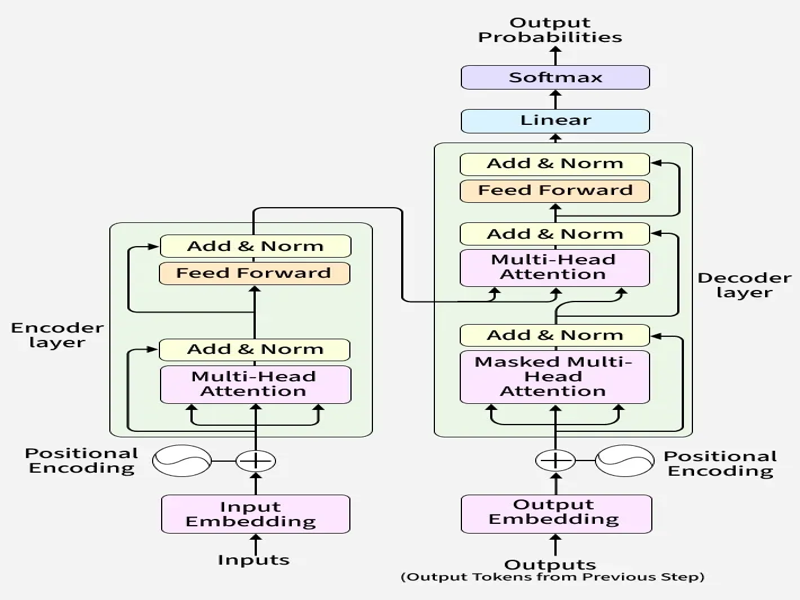

In [ ]:
from PIL import Image
from IPython.display import display

image = Image.open("/content/transformers.jpg.webp")

image = image.resize((800, 600))

display(image)

# 🔷 Encoder ও Decoder Layer — কাজ এবং তাদের মধ্যে Connection

ছবিতে যে **Transformer Architecture** দেখানো হয়েছে, সেখানে বামপাশে **Encoder** আর ডানপাশে **Decoder**। এখন এদের কাজ এবং একে অপরের সাথে কীভাবে communicate করে তা বিস্তারিত দেখি।

---

## 1️⃣ Encoder কী এবং এর কাজ কী?

**Encoder**-এর কাজ হলো **Input sentence-কে "বোঝা"** এবং একটা rich, contextual representation তৈরি করা — যা পরে Decoder ব্যবহার করবে।

### 🔹 Encoder-এর ভেতরে কী ঘটে (ছবি অনুযায়ী নিচ থেকে উপরে):

| ধাপ | কাজ |
|---|---|
| **Inputs** | Source sentence (যেমন: ইংরেজি sentence) |
| **Input Embedding** | প্রতিটি word-কে vector-এ রূপান্তর |
| **Positional Encoding** | Word-এর position/order তথ্য যোগ করা (sin/cos দিয়ে) |
| **Multi-Head Attention** | প্রতিটি word sentence-এর বাকি সব word-এর সাথে সম্পর্ক বের করে (Self-Attention) — **এখানে Mask নেই**, কারণ Encoder পুরো sentence একসাথে দেখতে পারে (আগে-পরে কোনো restriction নেই) |
| **Add & Norm** | Residual connection + normalization |
| **Feed Forward** | প্রতিটি position-এর representation আরও refine করা |
| **Add & Norm** | আবার residual + normalization |

এই পুরো ব্লকটা (Multi-Head Attention → Add&Norm → FFN → Add&Norm) **N বার repeat হয়** (Original paper-এ N = 6), অর্থাৎ Encoder-এর ৬টা identical layer একটার উপর একটা স্তুপ করা থাকে।

### 🔑 Encoder-এর Output কী?
Encoder শেষ পর্যন্ত input sentence-এর প্রতিটি word-এর জন্য একটা **contextualized vector** তৈরি করে — মানে প্রতিটা word-এর representation-এ পুরো sentence-এর context মিশে থাকে।

> উদাহরণ: "bank" শব্দটার representation আলাদা হবে "river bank" আর "money bank" sentence-এ — কারণ Encoder পুরো context দেখেই representation বানায়।

---

## 2️⃣ Decoder কী এবং এর কাজ কী?

**Decoder**-এর কাজ হলো Encoder-এর তৈরি করা representation ব্যবহার করে **output sentence generate করা**, একটা একটা করে word (auto-regressive ভাবে)।

### 🔹 Decoder-এর ভেতরে কী ঘটে (নিচ থেকে উপরে):

| ধাপ | কাজ |
|---|---|
| **Outputs (shifted right)** | এখন পর্যন্ত generate হওয়া output tokens (আগের step-এর predicted words) |
| **Output Embedding + Positional Encoding** | Input-এর মতোই embedding ও position তথ্য যোগ |
| **Masked Multi-Head Attention** | Decoder নিজের আগের output word-গুলোর সাথে attention করে, কিন্তু **ভবিষ্যতের word দেখতে পারে না** (mask দিয়ে hide করা) |
| **Add & Norm** | Residual + normalization |
| **Multi-Head Attention (মাঝেরটা)** | এটাই **Encoder-Decoder Attention** — এখানে Decoder, Encoder-এর output-কে দেখে (এটাই দুইটা অংশের মূল connection, নিচে বিস্তারিত) |
| **Add & Norm** | আবার residual + normalization |
| **Feed Forward** | Representation refine করা |
| **Add & Norm** | শেষ normalization |

এই ব্লকও **N বার repeat হয়** (৬ বার), তারপর:

| ধাপ | কাজ |
|---|---|
| **Linear** | Decoder-এর output কে vocabulary size-এর একটা vector-এ রূপান্তর |
| **Softmax** | প্রতিটা vocabulary word-এর probability বের করা |
| **Output Probabilities** | সবচেয়ে বেশি probability-ওয়ালা word-ই পরবর্তী output token |

---

## 3️⃣ Encoder আর Decoder কীভাবে Communicate করে? (মূল সংযোগ)

ছবিতে **তীর চিহ্ন** (arrows) যেগুলো Encoder থেকে বের হয়ে Decoder-এর মাঝের **Multi-Head Attention** ব্লকে ঢুকছে — এটাই মূল connection, যাকে বলে **Cross-Attention** বা **Encoder-Decoder Attention**।

### 🔑 এটা কীভাবে কাজ করে:

Decoder-এর মাঝের Multi-Head Attention layer-এ:

- **Query (Q)** আসে → **Decoder** থেকে (এখন পর্যন্ত যা generate হয়েছে তার representation)
- **Key (K)** এবং **Value (V)** আসে → **Encoder-এর output** থেকে

$$\text{Cross-Attention}(Q_{decoder}, K_{encoder}, V_{encoder})$$

### 🔍 সহজভাবে বুঝি — Translation Example দিয়ে:

ধরো, English → Bangla translation করছি: *"I love cats"* → *"আমি বিড়াল ভালোবাসি"*

1. **Encoder** প্রথমে পুরো *"I love cats"* sentence পড়ে প্রতিটা word-এর জন্য rich representation তৈরি করে
2. **Decoder** যখন *"বিড়াল"* (cat) শব্দটা generate করার চেষ্টা করছে, তখন **Cross-Attention**-এর মাধ্যমে সে Encoder-এর output-এ ফিরে গিয়ে দেখে — কোন English word-টা এখন সবচেয়ে relevant (এক্ষেত্রে "cats" word-টার representation-এ বেশি attention দিবে)
3. এভাবে প্রতিটা output word generate করার সময় Decoder, Encoder-এর পুরো input sentence-এর relevant অংশে "তাকিয়ে" দেখে নেয়

> এটাই মূল কারণ কেন Transformer এত ভালো translation/generation করতে পারে — Decoder প্রতিটা step-এ input sentence-এর **সঠিক অংশে ফোকাস** করতে পারে, পুরনো Seq2Seq-এর মতো একটামাত্র fixed vector-এর উপর নির্ভর করে না।

---


# 🔷 Self-Attention Calculation — Numerical Example (হাতে-কলমে হিসাব)

চলো একটা **ছোট, বাস্তব উদাহরণ** দিয়ে দেখি Self-Attention আসলে ভেতরে ভেতরে কীভাবে কাজ করে — একদম সংখ্যা ব্যবহার করে ধাপে ধাপে।

## 🎯 উদাহরণের Setup

ধরি আমাদের sentence-এ **৩টা word** আছে, আর প্রতিটা word-এর embedding dimension = **4**:

$$x_1 = [1, 0, 1, 0]$$
$$x_2 = [0, 2, 0, 2]$$
$$x_3 = [1, 1, 1, 1]$$

আর আমাদের **Weight Matrix** ($W_Q, W_K, W_V$) গুলো দেওয়া আছে (এগুলো training-এর মাধ্যমে শেখা হয়, এখানে উদাহরণের জন্য fixed ধরে নিচ্ছি), আর output dimension $d_k = 3$:

$$
W_Q = \begin{bmatrix} 1 & 0 & 1 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \\ 0 & 1 & 1 \end{bmatrix}
\quad
W_K = \begin{bmatrix} 0 & 0 & 1 \\ 1 & 1 & 0 \\ 0 & 1 & 0 \\ 1 & 1 & 0 \end{bmatrix}
\quad
W_V = \begin{bmatrix} 0 & 2 & 0 \\ 0 & 3 & 0 \\ 1 & 0 & 3 \\ 1 & 1 & 0 \end{bmatrix}
$$

---

## ধাপ ১: Query, Key, Value বের করা

প্রতিটা word vector-কে $W_Q, W_K, W_V$ দিয়ে গুণ করে Q, K, V বের করি:

$$Q = X \cdot W_Q, \quad K = X \cdot W_K, \quad V = X \cdot W_V$$

**হিসাব করার পর ফলাফল:**

| Word | Q (Query) | K (Key) | V (Value) |
|---|---|---|---|
| $x_1$ ("I") | [1, 0, 2] | [0, 1, 1] | [1, 2, 3] |
| $x_2$ ("love") | [2, 2, 2] | [4, 4, 0] | [2, 8, 0] |
| $x_3$ ("AI") | [2, 1, 3] | [2, 3, 1] | [2, 6, 3] |

> 💡 **মনে রাখো:** প্রতিটা word-এর জন্যই আলাদা Q, K, V vector তৈরি হয় — এই তিনটাই একই input থেকে আসে, শুধু আলাদা weight matrix দিয়ে transform হয়।

---

## ধাপ ২: Attention Score বের করা ($QK^T$)

এখন দেখব — **word 1 ("I")** sentence-এর বাকি word-গুলোর (নিজেসহ) সাথে কতটা "সম্পর্কিত"। এর জন্য $Q_1$-কে প্রতিটা $K$-এর সাথে **dot product** করি:

$$\text{score}(Q_1, K_1) = [1,0,2] \cdot [0,1,1] = (1{\times}0)+(0{\times}1)+(2{\times}1) = 2$$
$$\text{score}(Q_1, K_2) = [1,0,2] \cdot [4,4,0] = (1{\times}4)+(0{\times}4)+(2{\times}0) = 4$$
$$\text{score}(Q_1, K_3) = [1,0,2] \cdot [2,3,1] = (1{\times}2)+(0{\times}3)+(2{\times}1) = 4$$

**Raw Scores:** `[2, 4, 4]`

---

## ধাপ ৩: Scaling ($\sqrt{d_k}$ দিয়ে ভাগ করা)

Score গুলো বড় হয়ে গেলে softmax-এর gradient খুব ছোট হয়ে যায় (training অস্থির হয়ে পড়ে)। তাই ভাগ করি $\sqrt{d_k}$ দিয়ে, এখানে $d_k = 3$, তাই $\sqrt{3} \approx 1.732$:

$$\frac{2}{1.732} = 1.155, \quad \frac{4}{1.732} = 2.309, \quad \frac{4}{1.732} = 2.309$$

**Scaled Scores:** `[1.155, 2.309, 2.309]`

---

## ধাপ ৪: Softmax — Attention Weight বের করা

Softmax দিয়ে scores গুলোকে **probability distribution**-এ রূপান্তর করি (সব যোগফল = 1):

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

$$e^{1.155} = 3.17, \quad e^{2.309} = 10.07, \quad e^{2.309} = 10.07$$

$$\text{sum} = 3.17 + 10.07 + 10.07 = 23.31$$

$$\text{softmax} = \left[\frac{3.17}{23.31}, \frac{10.07}{23.31}, \frac{10.07}{23.31}\right] = [0.136,\ 0.432,\ 0.432]$$

> 🔑 **মানে কী?** Word "I" তার নিজের প্রতি ১৩.৬% attention দিচ্ছে, "love" এর প্রতি ৪৩.২%, আর "AI"-এর প্রতিও ৪৩.২%। অর্থাৎ "I" শব্দটা বোঝার সময় model "love" আর "AI" শব্দ দুটোর দিকে বেশি "মনোযোগ" দিচ্ছে।

---

## ধাপ ৫: Weighted Sum of Values — চূড়ান্ত Output

এখন এই attention weight গুলো দিয়ে প্রতিটা $V$ vector-কে গুণ করে যোগ করি:

$$\text{Output}_1 = 0.136 \times V_1 + 0.432 \times V_2 + 0.432 \times V_3$$

$$= 0.136 \times [1,2,3] + 0.432 \times [2,8,0] + 0.432 \times [2,6,3]$$

$$= [0.136, 0.272, 0.408] + [0.864, 3.456, 0] + [0.864, 2.592, 1.296]$$

$$\text{Output}_1 = [1.864,\ 6.32,\ 1.704]$$

> ✅ এটাই হলো word **"I"**-এর জন্য Self-Attention-এর **চূড়ান্ত output vector** — যেখানে এখন এই vector-এর ভেতরে "love" আর "AI" শব্দ দুটোর তথ্যও মিশে আছে (কারণ তাদের attention weight বেশি ছিল)।

---

## 🔁 একই প্রসেস বাকি word-গুলোর জন্যও হয়

$Q_2$ (word "love") ও $Q_3$ (word "AI") এর জন্যও **ঠিক একই ৫টা ধাপ** repeat হবে:
- $Q_2$ vs সব $K$ → score → scale → softmax → weighted sum of $V$ → $\text{Output}_2$
- $Q_3$ vs সব $K$ → score → scale → softmax → weighted sum of $V$ → $\text{Output}_3$

শেষে তিনটা output vector মিলিয়ে একটা matrix পাওয়া যায়, যেটাই হলো ওই layer-এর Self-Attention-এর **চূড়ান্ত ফলাফল** — যা পরবর্তী ধাপে (Add & Norm → Feed Forward) যায়।

---

## 📌 পুরো প্রসেসটা এক নজরে (Formula আকারে)

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

| ধাপ | কাজ |
|---|---|
| 1️⃣ | $X$ থেকে $Q, K, V$ বের করা (weight matrix দিয়ে গুণ) |
| 2️⃣ | $Q \cdot K^T$ → Attention Score (কে কার সাথে কতটা সম্পর্কিত) |
| 3️⃣ | $\sqrt{d_k}$ দিয়ে ভাগ (Scaling — স্থিতিশীলতার জন্য) |
| 4️⃣ | Softmax → probability distribution (Attention Weight) |
| 5️⃣ | Weight দিয়ে $V$-এর weighted sum → চূড়ান্ত Output |

---

## 🔑 সংক্ষেপে (Summary)

> Self-Attention আসলে খুব সহজ একটা গাণিতিক প্রসেস: প্রতিটা word তার **Query**-কে বাকি সব word-এর **Key**-এর সাথে তুলনা করে বুঝে নেয় কে কতটা গুরুত্বপূর্ণ (Score → Softmax), তারপর সেই গুরুত্ব অনুযায়ী বাকি word-গুলোর **Value**-কে মিশিয়ে (weighted sum) একটা নতুন, context-সমৃদ্ধ representation তৈরি করে। এই পুরো হিসাবটাই matrix multiplication দিয়ে হয় বলে GPU-তে খুব দ্রুত ও parallel-ly করা সম্ভব হয়।

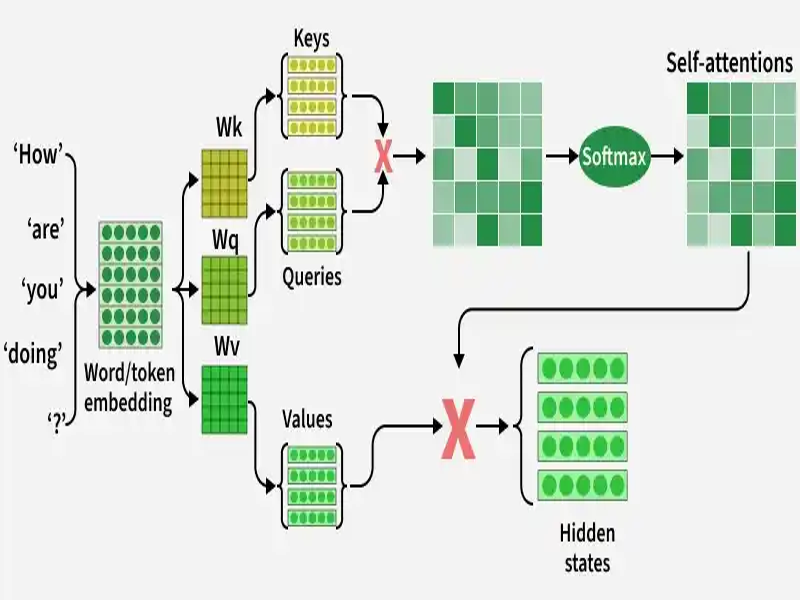

In [ ]:
from PIL import Image
from IPython.display import display

image = Image.open("/content/self_attention.webp")

image = image.resize((800, 600))

display(image)

# 🔷 Self-Attention Mechanism — বিস্তারিত ধারণা

## 1️⃣ Self-Attention কী?

**Self-Attention** হলো একটা mechanism যার মাধ্যমে একটা sentence-এর প্রতিটি word **একই sentence-এর বাকি সব word**-এর সাথে নিজের সম্পর্ক (relationship) হিসাব করে — এবং সেই সম্পর্কের ভিত্তিতে নিজের representation-কে **আপডেট/সমৃদ্ধ** করে।

এখানে "Self" শব্দটা এসেছে কারণ — attention hisab হচ্ছে sentence-টার **নিজের ভেতরেই** (word নিজের sentence-এর অন্য word-এর সাথে তুলনা করছে, বাইরের কোনো sentence-এর সাথে না)।

> সহজ কথায়: প্রতিটা word sentence পড়ার সময় বাকি word-গুলোর দিকে "তাকিয়ে" বুঝে নেয় — কোন word তাকে বুঝতে সাহায্য করছে বেশি, আর কোনটা কম।

---

## 2️⃣ Self-Attention না থাকলে (RNN/LSTM-based Encoder-Decoder) কী সমস্যা হতো?

Self-Attention আসার আগে Encoder-Decoder model (RNN/LSTM দিয়ে তৈরি) নিচের সমস্যাগুলোতে ভুগতো:

### ❌ Problem 1: Fixed-size Context Vector (Information Bottleneck)
পুরনো Encoder-Decoder-এ Encoder পুরো input sentence পড়ে একটা **একটামাত্র fixed-size vector**-এ পুরো তথ্য compress করতো। Decoder পুরো output generate করার সময় শুধু এই **একটা vector**-এর উপর নির্ভর করতো।
- Sentence বড় হলে শুরুর দিকের word-এর তথ্য এই একটা vector-এ ঠিকমতো ধরে রাখা যেত না — তথ্য হারিয়ে যেত

### ❌ Problem 2: Sequential Dependency (এক এক করে প্রসেসিং)
RNN word-গুলো এক এক করে ক্রমানুসারে প্রসেস করতো:
$$h_t = f(h_{t-1}, x_t)$$
- এর ফলে **parallel computation** সম্ভব হতো না → training অনেক ধীর
- দূরের word-এর মধ্যে সম্পর্ক বুঝতে model-কে বহু step পার হতে হতো

### ❌ Problem 3: Long-Range Dependency হারানো (Vanishing Gradient)
Sentence যত লম্বা হতো, শুরুর word-এর প্রভাব শেষের দিকে পৌঁছাতে পৌঁছাতে তত ক্ষীণ হয়ে যেত।
- উদাহরণ: *"The trophy didn't fit in the suitcase because **it** was too big."*
- এখানে "it" যে "trophy"-কে বোঝাচ্ছে (suitcase-কে না) — এটা বুঝতে হলে model-কে অনেক distance পার হয়ে সম্পর্ক ধরে রাখতে হয়, যা RNN-এর জন্য কঠিন ছিল

### ❌ Problem 4: প্রতিটা word-এর জন্য আলাদা "focus" ছিল না
RNN/LSTM-এ Decoder প্রতিটা output word generate করার সময় input sentence-এর **সব অংশে সমান গুরুত্ব** দিতো (বা একটামাত্র compressed vector দেখতো) — কোন input word এই মুহূর্তে বেশি গুরুত্বপূর্ণ, সেটা আলাদাভাবে বোঝার উপায় ছিল না।

---

## 3️⃣ Self-Attention এই সমস্যাগুলো কীভাবে সমাধান করলো?

| সমস্যা | Self-Attention-এর সমাধান |
|---|---|
| Fixed-size context vector | প্রতিটা word-এর জন্য **আলাদা, dynamic representation** তৈরি হয় — কোনো একক bottleneck vector নেই |
| Sequential dependency | সব word-এর attention score **একসাথে (parallel-ly) matrix multiplication দিয়ে** হিসাব হয় |
| Long-range dependency | যেকোনো দুই word-এর মধ্যে দূরত্ব যতই হোক, **সরাসরি এক ধাপে** (direct connection) সম্পর্ক হিসাব হয় — মাঝখানে কোনো step পার হতে হয় না |
| Fixed focus না থাকা | প্রতিটা word প্রতিবার **নতুন করে dynamic ভাবে** ঠিক করে কোন word-এর দিকে কতটা attention দিবে (attention weight/probability দিয়ে) |

> 🔑 **মূল সমাধান:** Self-Attention প্রতিটা word-কে সরাসরি sentence-এর **সব** word-এর সাথে (নিজেসহ) তুলনা করার সুযোগ দেয় একটা single matrix operation-এ — ফলে না তথ্য হারায়, না সময় বেশি লাগে।

---

## 4️⃣ Self-Attention Mechanism বোঝা (Q, K, V দিয়ে)

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q, K, V** = Query, Key, Value matrices (word representation থেকে তৈরি)
- **$d_k$** = Key vector-এর dimension

Self-Attention প্রতিটা word-কে sentence-এর সব word-এর সাথে সম্পর্ক হিসাব করতে দেয় — ফলে প্রতিটা word-এর জন্য একটা **rich, context-aware representation** তৈরি হয়, যেখানে sentence-এর প্রাসঙ্গিক (relevant) সব তথ্য মিশে থাকে।

---

## 5️⃣ ছবির Diagram অনুযায়ী ধাপে ধাপে ব্যাখ্যা ("How are you doing?" Example)

ছবিতে sentence: **"How", "are", "you", "doing", "?"** — এই ৫টা word নিয়ে পুরো প্রসেসটা দেখানো হয়েছে। চলো ধাপে ধাপে দেখি:

### 🔹 Step 1: Word/Token Embedding
প্রতিটা word ("How", "are", "you", "doing", "?") কে প্রথমে একটা **vector (embedding)**-এ রূপান্তর করা হয় — ছবিতে সবুজ ডট-এর column matrix হিসেবে দেখানো হয়েছে। এটাই model-এর input representation।

### 🔹 Step 2: তিনটা Weight Matrix দিয়ে Q, K, V তৈরি
Embedding matrix-কে তিনটা **আলাদা learned weight matrix** দিয়ে গুণ করা হয়:
- $W_K$ (হলুদ) দিয়ে গুণ করে → **Keys** matrix
- $W_Q$ (হালকা সবুজ) দিয়ে গুণ করে → **Queries** matrix
- $W_V$ (গাঢ় সবুজ) দিয়ে গুণ করে → **Values** matrix

> প্রতিটা word-এর জন্য এখন তিনটা করে vector আছে: একটা Query, একটা Key, একটা Value।

### 🔹 Step 3: Queries × Keys (Attention Score Matrix)
Queries matrix ও Keys matrix-কে **matrix multiplication (X চিহ্ন)** করা হয় — ফলে একটা **5×5 score matrix** তৈরি হয় (কারণ sentence-এ ৫টা word)।
- এই matrix-এর প্রতিটা cell বোঝায় — একটা word আরেকটা word-এর সাথে কতটা "সম্পর্কিত" (raw attention score)
- ছবিতে এটাকে সবুজ শেডের grid হিসেবে দেখানো হয়েছে — গাঢ় রং মানে বেশি সম্পর্ক, হালকা রং মানে কম

### 🔹 Step 4: Softmax
এই raw score matrix-কে **Softmax** function দিয়ে পাস করানো হয় — ফলে প্রতিটা row-এর মান probability-তে (0 থেকে 1, যোগফল 1) রূপান্তরিত হয়।
- ফলাফল হলো **Self-Attentions matrix** (ছবির ডানপাশে উপরে) — এটাই চূড়ান্ত **Attention Weight**, যা বলে দেয় প্রতিটা word বাকি word-গুলোকে ঠিক কতটা গুরুত্ব দিচ্ছে

### 🔹 Step 5: Attention Weights × Values
Softmax থেকে পাওয়া Self-Attention matrix-কে **Values matrix**-এর সাথে আবার multiply (দ্বিতীয় X চিহ্ন) করা হয়।
- এর ফলে প্রতিটা word-এর জন্য একটা নতুন vector তৈরি হয়, যেখানে গুরুত্বপূর্ণ word-গুলোর তথ্য বেশি মাত্রায় মিশে থাকে

### 🔹 Step 6: Hidden States (চূড়ান্ত Output)
শেষে যে output পাওয়া যায় তাকে বলে **Hidden States** — এটাই প্রতিটা word ("How", "are", "you", "doing", "?") এর জন্য নতুন, **context-সমৃদ্ধ representation**।

> উদাহরণস্বরূপ, "you" শব্দটার নতুন hidden state-এ এখন "How", "are", "doing" শব্দগুলোর প্রাসঙ্গিক তথ্যও মিশে থাকবে — শুধু "you" শব্দটার নিজের অর্থ না।

---

## 📌 পুরো প্রসেসটা এক নজরে


Word Embedding

↓

┌───┬───┬───┐

│Wk │Wq │Wv │ → তিনটা আলাদা Linear Transformation

└───┴───┴───┘

↓   ↓    ↓

Keys Queries Values

↘ ↙

Queries × Keys → Score Matrix

↓

Softmax

↓

Self-Attention Weights

↓

Self-Attention × Values

↓

Hidden States (চূড়ান্ত Output)



---

## 🔑 সংক্ষেপে (Summary)

> **Self-Attention** হলো এমন একটা mechanism যা একটা sentence-এর প্রতিটা word-কে বাকি সব word-এর সাথে (Q-K-V দিয়ে) সরাসরি তুলনা করে, dynamic ভাবে গুরুত্ব (attention weight) ঠিক করে দেয়। এটা না থাকলে (RNN-based Encoder-Decoder-এ) fixed context vector-এর কারণে তথ্য হারানো, sequential processing-এর কারণে ধীরগতি, আর long-range dependency ধরতে না পারার সমস্যা হতো। Self-Attention এই সবগুলো সমস্যা একসাথে সমাধান করেছে — প্রতিটা word-কে সরাসরি, parallel-ly, এবং dynamically বাকি সব word-এর সাথে সংযুক্ত করে দিয়ে, যার ফলাফল হলো প্রতিটা word-এর জন্য একটা rich **Hidden State** representation।

# 🔷 Mathematical Terms & Formula-এর পেছনের যুক্তি (কেন এমন করা হলো?)

আগের উদাহরণে আমরা দেখেছি **কীভাবে** হিসাব হয়। এখন দেখব **কেন** প্রতিটা ধাপ ঠিক এভাবেই করা হয় — Dot Product কেন, Scaling ($\sqrt{d_k}$) কেন, Softmax কেনই বা নেওয়া হয়।

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

---

## 1️⃣ কেন Q, K, V — তিনটা আলাদা vector দরকার হলো?

এটাই সবচেয়ে common confusion। কেন একটা word থেকে একটামাত্র vector না নিয়ে তিনটা আলাদা vector (Query, Key, Value) বানানো হলো?

### 🔑 Analogy: Library System
কল্পনা করো তুমি একটা **লাইব্রেরিতে বই খুঁজছো**:
- **Query (Q)** = তোমার **প্রশ্ন/অনুসন্ধান** — "আমি এমন বই খুঁজছি যেখানে History সম্পর্কে লেখা আছে"
- **Key (K)** = প্রতিটা বইয়ের **ট্যাগ/লেবেল** — যেটা বলে দেয় বইটা কী বিষয়ে
- **Value (V)** = বইটার **আসল কন্টেন্ট**

তুমি তোমার Query-কে প্রতিটা বইয়ের Key-এর সাথে মিলাও (কতটা match করে দেখো), যেই বইয়ের Key তোমার Query-এর সাথে সবচেয়ে বেশি মিলবে, সেই বইয়ের Value (কন্টেন্ট) তুমি বেশি গুরুত্ব দিয়ে পড়বে।

### কেন একই vector দিয়ে এই তিনটা কাজ করা গেল না?
যদি একটা word শুধু একটামাত্র vector দিয়ে "আমি কী খুঁজছি" (Query role), "আমি কী অফার করছি" (Key role), আর "আমার আসল তথ্য" (Value role) — এই তিনটা কাজই করতে চাইতো, তাহলে vector-টার উপর অনেক বেশি চাপ পড়তো এবং প্রতিটা role আলাদাভাবে ভালোভাবে শিখতে পারতো না।

**আলাদা weight matrix ($W_Q, W_K, W_V$)** দিয়ে vector তিনটা আলাদা করে দেওয়ায় model-কে **flexibility** দেওয়া হয় — একই word ভিন্ন ভিন্ন role-এ ভিন্নভাবে represent হতে পারে, আর training-এর মাধ্যমে model নিজেই শিখে নেয় কীভাবে এই তিনটা role optimal ভাবে সেট করতে হবে।

---

## 2️⃣ কেন $Q \cdot K^T$ (Dot Product) নেওয়া হয়?

### 🔑 Dot Product আসলে কী মাপে?
দুইটা vector-এর **Dot Product** হলো তাদের মধ্যে **similarity/alignment** মাপার একটা সহজ ও efficient উপায়।

$$Q \cdot K = |Q||K|\cos\theta$$

- যদি দুইটা vector একই দিকে (direction) নির্দেশ করে (অর্থাৎ semantically related/similar) → $\cos\theta \approx 1$ → Dot Product **বড়** হবে
- যদি দুইটা vector সম্পূর্ণ ভিন্ন/unrelated হয় → $\cos\theta \approx 0$ → Dot Product **ছোট/শূন্যের কাছাকাছি** হবে

### কেন Dot Product-ই বেছে নেওয়া হলো (অন্য কোনো similarity measure না নিয়ে)?
- **Computational Efficiency**: Dot product হলো শুধুই matrix multiplication — GPU-তে এটা **অত্যন্ত দ্রুত** করা যায় (highly parallelizable)
- অন্য similarity measure (যেমন cosine similarity আলাদাভাবে normalize করে বের করা, বা neural network দিয়ে score বের করা - "Additive Attention") তুলনামূলক **ধীর এবং বেশি computation-heavy**
- Original Transformer paper-এ Dot-Product Attention আর Additive Attention দুটোই test করা হয়েছিল — dot product **সমান কার্যকর কিন্তু অনেক দ্রুত** ছিল বলেই এটা বেছে নেওয়া হয়

> 🔑 **সারকথা:** $QK^T$ বের করার মানে হলো — "প্রতিটা word-এর Query, বাকি সব word-এর Key-এর সাথে কতটা 'align' করে (semantically কতটা কাছাকাছি) সেটা এক ধাক্কায় (matrix multiplication দিয়ে) মেপে ফেলা।"

---

## 3️⃣ কেন Scaling ($\sqrt{d_k}$ দিয়ে ভাগ) করা হয়?

এটাই সবচেয়ে বেশি ভুল বোঝা হয় এমন একটা ধাপ। কেন এই ভাগটা লাগে দেখি:

### 🔴 সমস্যা: Dimension বাড়লে Dot Product-এর মান অনেক বড় হয়ে যায়

ধরো $Q$ আর $K$ এর প্রতিটা component একটা random variable, mean = 0, variance = 1। তাহলে $Q \cdot K = \sum_{i=1}^{d_k} q_i k_i$।

- Dot product-এর **variance** হয় $d_k$ (dimension-এর সমানুপাতিক)
- মানে $d_k$ যত বড় হবে (ধরো, ৬৪ বা ৫১২), Dot product-এর মানও **তত বড় হয়ে যাবে** (উদাহরণে আমরা যদিও ছোট সংখ্যা পেয়েছিলাম $d_k=3$ হওয়ায়, কিন্তু বাস্তব model-এ $d_k$ অনেক বড় হয়)

### 🔴 এই বড় মান Softmax-এ কী সমস্যা করে?
Softmax function:
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

যখন input value গুলো **খুব বড়** হয়, তখন softmax-এর output প্রায় **one-hot vector**-এর মতো হয়ে যায় (একটা মান প্রায় 1, বাকিগুলো প্রায় 0)।

**এতে দুইটা সমস্যা হয়:**
1. **Gradient Vanishing**: Softmax যখন এমন extreme (0 বা 1-এর কাছাকাছি) হয়ে যায়, তখন এর **gradient** (derivative) প্রায় শূন্য হয়ে যায় — এর মানে backpropagation-এর সময় weight update প্রায় বন্ধ হয়ে যায়, model শিখতে পারে না
2. Model শুধু **একটামাত্র word**-এর দিকে extreme attention দিয়ে ফেলে, বাকি সব word-এর তথ্য পুরোপুরি ignore করে ফেলে — যা আমরা চাই না (আমরা চাই soft, balanced attention distribution)

### ✅ সমাধান: $\sqrt{d_k}$ দিয়ে ভাগ করা
$$\frac{QK^T}{\sqrt{d_k}}$$

- ভাগ করলে Dot product-এর **variance আবার 1-এ ফিরে আসে** (গাণিতিকভাবে প্রমাণিত)
- ফলে score গুলো একটা **reasonable range**-এ থাকে
- Softmax তখন **smoother, balanced** probability distribution দেয় — gradient ভালোভাবে flow করে, model efficiently train হয়

> 🔑 **সহজ ভাষায়:** dimension ($d_k$) বাড়লে raw score-ও বড় হতে থাকে অনিয়ন্ত্রিতভাবে। $\sqrt{d_k}$ দিয়ে ভাগ করাটা একটা "normalization" — যাতে score-এর scale সবসময় প্রায় একই (stable) থাকে, dimension যত বড়ই হোক না কেন।

---

## 4️⃣ কেন Softmax নেওয়া হয়?

Scaling-এর পরে আমরা পাই raw (scaled) scores — যেমন `[1.155, 2.309, 2.309]`। এগুলো এখনো শুধুই সংখ্যা, এদের কোনো নির্দিষ্ট অর্থ (interpretation) নেই। Softmax এখানে তিনটা গুরুত্বপূর্ণ কাজ করে:

### 🔑 কাজ ১: Score-কে Probability-তে রূপান্তর
Softmax প্রতিটা score-কে এমনভাবে রূপান্তর করে যে:
- সব output **0 থেকে 1**-এর মধ্যে থাকে
- সব output-এর **যোগফল ঠিক 1** হয়

এর ফলে আমরা এই মানগুলোকে সরাসরি **"attention weight" বা percentage** হিসেবে interpret করতে পারি — যেমন "word 1, word 2-কে ৪৩% গুরুত্ব দিচ্ছে"।

### 🔑 কাজ ২: বড় score-কে বেশি গুরুত্ব, ছোট score-কে কম গুরুত্ব (কিন্তু সম্পূর্ণ বাদ না দিয়ে)
Softmax **exponential function** ($e^x$) ব্যবহার করে বলে:
- যেই word-এর score তুলনামূলক বেশি, সেটা **exponentially বেশি গুরুত্ব** পায়
- কিন্তু ছোট score-ওয়ালা word-ও **সম্পূর্ণ শূন্য হয়ে যায় না** (যদি scaling ঠিকভাবে করা থাকে) — এটা soft weighting, hard selection না

### 🔑 কাজ ৩: Differentiable (Gradient-friendly)
Softmax একটা **smooth, differentiable function** — মানে backpropagation-এর সময় এর derivative হিসাব করা যায়, ফলে neural network **gradient descent দিয়ে train** হতে পারে। (যদি আমরা শুধু "সবচেয়ে বেশি score-ওয়ালা word-টাকেই বেছে নাও" — এরকম hard selection (যেমন argmax) করতাম, সেটা differentiable হতো না, model train করা যেত না)

> 🔑 **সহজ ভাষায়:** Softmax raw score-গুলোকে এমন একটা "শতকরা ভাগ"-এ রূপান্তর করে দেয় যা দিয়ে বোঝা যায় — প্রতিটা word বাকি word-গুলোকে ঠিক কত শতাংশ গুরুত্ব দিচ্ছে, এবং এই রূপান্তরটা এমনভাবে হয় যাতে model gradient দিয়ে শিখতে পারে।

---

## 5️⃣ কেন শেষে Value ($V$) দিয়ে গুণ করা হয় (Weighted Sum)?

এতক্ষণ আমরা যা পেয়েছি সেটা হলো — **attention weight** (কোন word কাকে কতটা গুরুত্ব দিচ্ছে)। কিন্তু এটা শুধু একটা "গুরুত্বের percentage", এখনো কোনো **actual information/content** বহন করছে না।

- **Value ($V$)** হলো প্রতিটা word-এর **প্রকৃত তথ্য (content)**
- Attention weight দিয়ে Value-কে গুণ করে যোগ করলে (weighted sum), আমরা পাই একটা নতুন vector যেখানে **গুরুত্বপূর্ণ word-গুলোর তথ্য বেশি পরিমাণে, আর কম গুরুত্বপূর্ণ word-গুলোর তথ্য কম পরিমাণে** মিশে আছে

$$\text{Output} = 0.136 \times V_1 + 0.432 \times V_2 + 0.432 \times V_3$$

> এটাই আসলে "attention" কনসেপ্টের মূল কথা — "আমি সব তথ্যের দিকেই কিছুটা তাকাই, কিন্তু যেটা বেশি গুরুত্বপূর্ণ তার দিকে বেশি তাকাই" — ঠিক যেমন মানুষ পড়ার সময় করে।

---

## 📌 প্রতিটা ধাপের "কেন" — এক নজরে সারাংশ

| ধাপ | কী করা হয় | কেন করা হয় |
|---|---|---|
| **Q, K, V তৈরি** | তিনটা আলাদা weight matrix দিয়ে transform | একই word-কে তিনটা ভিন্ন role-এ flexibly represent করতে |
| **$QK^T$ (Dot Product)** | Query আর Key-এর মধ্যে similarity মাপা | দ্রুত, efficient ভাবে দুই word কতটা related তা বের করতে |
| **$\sqrt{d_k}$ দিয়ে Scale** | Score-কে ছোট করে আনা | Dimension বড় হলে score অনিয়ন্ত্রিতভাবে বড় হয়ে যাওয়া ঠেকিয়ে, softmax-কে stable রাখতে (gradient vanishing এড়াতে) |
| **Softmax** | Score-কে probability-তে রূপান্তর | Interpretable, normalized (sum=1), soft (সম্পূর্ণ বাদ না দেওয়া), এবং differentiable (trainable) attention weight পেতে |
| **Value দিয়ে গুণ (Weighted Sum)** | Attention weight × actual content | শুধু "গুরুত্ব" না, প্রকৃত তথ্যও যোগ করে একটা context-rich representation তৈরি করতে |

---

## 🔑 সংক্ষেপে (Summary)

> Self-Attention-এর প্রতিটা গাণিতিক ধাপ **উদ্দেশ্যপূর্ণভাবে** ডিজাইন করা: **Dot Product** ব্যবহার হয় কারণ এটা দ্রুত ও কার্যকরভাবে দুই word-এর সম্পর্ক (similarity) মাপে। **Scaling ($\sqrt{d_k}$)** দরকার হয় কারণ dimension বাড়লে raw score অতিরিক্ত বড় হয়ে softmax-কে অস্থির করে ফেলে (gradient vanish করে) — এটা সেটা প্রতিরোধ করে। **Softmax** দরকার হয় কারণ raw score-কে একটা normalized, interpretable, এবং trainable (differentiable) probability distribution-এ রূপান্তর করতে হয়। আর শেষে **Value দিয়ে গুণ** করা হয় কারণ শুধু "কে কতটা গুরুত্বপূর্ণ" জানলেই হবে না, সেই গুরুত্ব অনুযায়ী **প্রকৃত তথ্যও** মিশিয়ে একটা নতুন representation তৈরি করতে হবে।

# 🔷 Multi-Head Attention — বিস্তারিত ধারণা

## 1️⃣ Multi-Head Attention কী?

**Multi-Head Attention** হলো Self-Attention-এরই একটা উন্নত ভার্সন, যেখানে একবার attention হিসাব করার বদলে, **একই input-এর উপর একাধিকবার (parallel-ly) আলাদা আলাদা "head" দিয়ে attention হিসাব করা হয়** — এবং শেষে সবগুলোর ফলাফল একসাথে মিলিয়ে ফেলা হয়।

> সহজ ভাষায়: একটা sentence-কে একজন মানুষ একবার পড়ার বদলে, **৮ জন আলাদা মানুষ একই sentence একসাথে পড়ছে**, প্রত্যেকে **ভিন্ন ভিন্ন দৃষ্টিকোণ (perspective)** থেকে — একজন হয়তো grammar-এর দিকে খেয়াল করছে, আরেকজন meaning-এর দিকে, আরেকজন কোন word কোন word-কে refer করছে সেদিকে — শেষে সবার observation একসাথে করে একটা সম্পূর্ণ ধারণা তৈরি হচ্ছে।

---

## 2️⃣ Multi-Head Attention কেন দরকার হলো?

### 🔴 Problem: Single-Head Attention-এর সীমাবদ্ধতা

আগে আমরা যে Self-Attention দেখেছি (single head), সেখানে একটা word তার Q, K, V দিয়ে **একটামাত্র "attention pattern"** শিখতে পারে।

কিন্তু বাস্তবে একটা sentence-এ একই সাথে **অনেক ধরনের সম্পর্ক** থাকে:

> উদাহরণ: *"The cat sat on the mat because it was tired."*

এই sentence বুঝতে হলে একসাথে অনেক কিছু ধরতে হয়:
- **Syntactic (ব্যাকরণগত) সম্পর্ক** → "cat" আর "sat" (subject-verb সম্পর্ক)
- **Coreference (কে কাকে বোঝাচ্ছে)** → "it" আসলে "cat"-কে বোঝাচ্ছে, "mat"-কে না
- **Positional/local সম্পর্ক** → পাশাপাশি word-গুলোর সম্পর্ক ("on the mat")
- **Semantic (অর্থগত) সম্পর্ক** → "tired" কেন হলো তার কারণ ("because")

**একটামাত্র attention head** দিয়ে এই সবগুলো ভিন্ন ধরনের সম্পর্ক **একসাথে ভালোভাবে ধরা কঠিন** — কারণ একটা head-এর একটাই $W_Q, W_K, W_V$ থাকে, ফলে সে একটা "average" বা "compromise" ধরনের attention pattern শিখে ফেলে, যেটা কোনো একটা সম্পর্কের জন্যই optimal হয় না।

### ✅ Multi-Head Attention-এর সমাধান
একাধিক head থাকলে, **প্রতিটা head আলাদা $W_Q, W_K, W_V$ শেখে**, ফলে প্রতিটা head **আলাদা আলাদা ধরনের সম্পর্ক/pattern** শিখতে পারে — একটা head হয়তো grammar ধরবে, আরেকটা coreference, আরেকটা কিছু ভিন্ন কিছু — সব মিলিয়ে model অনেক বেশি **rich এবং বহুমাত্রিক (multi-dimensional)** representation তৈরি করতে পারে।

---

## 3️⃣ Multi-Head Attention-এ কী কী Component থাকে?

| Component | কাজ |
|---|---|
| **$h$ (Number of Heads)** | কতগুলো আলাদা attention head থাকবে (Original paper-এ $h = 8$) |
| **$W_Q^i, W_K^i, W_V^i$** | প্রতিটা head-এর জন্য আলাদা weight matrix ($i$ = head number, $1$ থেকে $h$ পর্যন্ত) |
| **Scaled Dot-Product Attention** | প্রতিটা head-এর ভেতরে আলাদাভাবে চলে (যা আমরা আগে শিখেছি) |
| **Concatenation** | সব head-এর output একসাথে জোড়া লাগানো (concatenate) |
| **$W^O$ (Output Weight Matrix)** | Concatenated output-কে আবার একটা final linear transformation দিয়ে সঠিক dimension-এ ফিরিয়ে আনা |

---

## 4️⃣ Multi-Head Attention কীভাবে কাজ করে? (ধাপে ধাপে)

ধরি, input embedding dimension $d_{model} = 512$, আর head সংখ্যা $h = 8$।

### 🔹 Step 1: Input-কে প্রতিটা Head-এর জন্য আলাদাভাবে Project করা
মূল input $X$ (dimension 512) কে **প্রতিটা head-এর জন্য আলাদা** $W_Q^i, W_K^i, W_V^i$ দিয়ে গুণ করে ছোট dimension-এ (সাধারণত $d_k = d_{model}/h = 512/8 = 64$) নামিয়ে আনা হয়:

$$Q_i = X W_Q^i, \quad K_i = X W_K^i, \quad V_i = X W_V^i \quad \text{(each of dimension 64)}$$

> 🔑 লক্ষ্য করো: প্রতিটা head ছোট dimension-এ (64) কাজ করে, পুরো 512 dimension-এ না — এতে total computational cost প্রায় single-head attention-এর সমানই থাকে, কিন্তু ৮টা ভিন্ন "দৃষ্টিকোণ" পাওয়া যায়।

### 🔹 Step 2: প্রতিটা Head আলাদাভাবে Scaled Dot-Product Attention করে
প্রতিটা head ($i = 1$ থেকে $8$) নিজের মতো করে আগের সেই familiar প্রসেস চালায়:

$$\text{head}_i = \text{Attention}(Q_i, K_i, V_i) = \text{softmax}\left(\frac{Q_i K_i^T}{\sqrt{d_k}}\right)V_i$$

এই ৮টা head **সম্পূর্ণ স্বাধীনভাবে, parallel-ly** কাজ করে — একটা আরেকটার উপর নির্ভর করে না।

### 🔹 Step 3: সব Head-এর Output Concatenate করা
৮টা head থেকে ৮টা output vector (প্রতিটার dimension 64) পাওয়া যায়। এগুলোকে পাশাপাশি জোড়া লাগানো হয় (concatenate):

$$\text{Concat}(\text{head}_1, \text{head}_2, \ldots, \text{head}_8)$$

$8 \times 64 = 512$ — অর্থাৎ concatenate করার পর আবার original dimension (512)-এ ফিরে আসে।

### 🔹 Step 4: চূড়ান্ত Linear Transformation
Concatenated output-কে আরেকটা weight matrix $W^O$ দিয়ে গুণ করা হয়, যাতে সব head-এর তথ্য একসাথে ভালোভাবে "মিশে" যায় এবং সঠিক output dimension পাওয়া যায়:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

---

## 5️⃣ পূর্ণাঙ্গ Formula

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W^O$$

$$\text{যেখানে,} \quad \text{head}_i = \text{Attention}(QW_Q^i,\ KW_K^i,\ VW_V^i)$$

$$\text{এবং,} \quad \text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Dimension সংক্রান্ত:**
- $d_{model}$ = মূল embedding dimension (যেমন 512)
- $h$ = head সংখ্যা (যেমন 8)
- $d_k = d_v = d_{model}/h$ = প্রতিটা head-এর dimension (যেমন 64)

---

## 6️⃣ চিত্রের মাধ্যমে বোঝা যাক


Input Embedding (dim=512)

↓

┌──────────────────────────────────────────┐

│ Head 1 Head 2 ... Head 8 │

│ Q₁K₁V₁ → Q₂K₂V₂ → Q₈K₈V₈ → │

│ Attention₁ Attention₂ Attention₈│

│ (dim=64) (dim=64) (dim=64) │

└──────────────────────────────────────────┘

↓ ↓ ↓

└─────── Concatenate ────────────┘

↓

(dim = 8×64 = 512)

↓

Linear (W^O দিয়ে গুণ)

↓

Final Multi-Head Attention Output


---

## 7️⃣ Single-Head vs Multi-Head — পার্থক্য

| বিষয় | Single-Head Attention | Multi-Head Attention |
|---|---|---|
| **Attention Pattern** | একটামাত্র শেখে | একাধিক (৮টা) আলাদা pattern শেখে |
| **Representation Power** | সীমিত — একটা "compromise" pattern | সমৃদ্ধ — বিভিন্ন relationship (syntax, semantic, coreference) আলাদাভাবে ধরতে পারে |
| **Dimension per head** | পুরো $d_{model}$ (যেমন 512) | ছোট, $d_{model}/h$ (যেমন 64) |
| **Computational Cost** | — | প্রায় একই (কারণ head-গুলো ছোট dimension-এ চলে, parallel-ly) |
| **Robustness** | একটা head ভুল করলে পুরো representation প্রভাবিত হয় | একটা head দুর্বল হলেও বাকি head গুলো compensate করতে পারে |

---

## 🔑 সংক্ষেপে (Summary)

> **Multi-Head Attention** দরকার হয়েছিল কারণ একটা sentence-এ একসাথে অনেক ধরনের সম্পর্ক (grammar, meaning, coreference ইত্যাদি) থাকে, যা **একটা মাত্র attention head** দিয়ে ভালোভাবে ধরা যায় না। তাই input-কে **একাধিক (সাধারণত ৮টা) ছোট "head"-এ ভাগ করে**, প্রতিটা head আলাদা $W_Q, W_K, W_V$ দিয়ে **স্বাধীনভাবে, parallel-ly** attention হিসাব করে — প্রতিটা head একটা ভিন্ন ধরনের সম্পর্ক শিখতে পারে। শেষে সব head-এর output **concatenate** করে একটা final weight matrix ($W^O$) দিয়ে transform করা হয়, যাতে একটা সমৃদ্ধ, বহুমাত্রিক representation পাওয়া যায় — এবং যেহেতু প্রতিটা head ছোট dimension-এ কাজ করে, তাই এই পুরো প্রসেসের computational cost single-head attention-এর প্রায় সমানই থাকে।


# Reference of Multi-Head Attention : https://www.geeksforgeeks.org/nlp/multi-head-attention-mechanism

Implementing Multi-head Attention using PyTorch

Step 1: Imports

Importing all necessary libraries for tensor manipulations and neural network building.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

## Step 2: Scaled Dot-Product Attention Function

This is the core of self-attention:

$$
\text{Attention}(Q,K,V)
=
\text{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
$$

### Explanation

- **Q (Query), K (Key), and V (Value)** are derived from the same source in self-attention.
- It results in values, i.e., the **weighted sum of Value (V)** for each position and head.
- **Softmax** ensures that the attention weights sum to **1**.
- If masking is used, irrelevant positions (such as future tokens or padding) are assigned large negative values in the logits. Therefore, after applying softmax, their attention weights become **0**.

In [ ]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    # (batch, heads, seq_len, head_dim) @ (batch, heads, head_dim, seq_len) --> (batch, heads, seq_len, seq_len)
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    # (batch, heads, seq_len, seq_len) @ (batch, heads, seq_len, head_dim) --> (batch, heads, seq_len, head_dim)
    values = torch.matmul(attention, v)
    return values, attention

# Step 3: Multi-Head Attention Class

Every step mimics the original Transformer:

- Project to QKV,
- Reshape for multiple heads,
- Split into Q, K, V,
- Compute attention,
- Concatenate heads,
- Linear output.

In [ ]:
class MultiheadAttention(nn.Module):
    def __init__(self, input_dim, d_model, num_heads):
        super().__init__()
        self.input_dim = input_dim      # Input embedding size
        self.d_model = d_model          # Model embedding size (output of self-attention)
        self.num_heads = num_heads      # Number of parallel attention heads
        self.head_dim = d_model // num_heads  # Dimensionality per head

        # For efficiency, compute Q, K, V for all heads at once with a single linear layer
        self.qkv_layer = nn.Linear(input_dim, 3 * d_model)
        # Final projection, combines all heads' outputs
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, sequence_length, input_dim = x.size()
        print(f"x.size(): {x.size()}")  # Input shape

        # Step 1: Project x into concatenated q, k, v for ALL heads at once
        qkv = self.qkv_layer(x)
        print(f"qkv.size(): {qkv.size()}")  # Shape: (batch, seq_len, 3 * d_model)

        # Step 2: reshape into (batch, seq_len, num_heads, 3 * head_dim)
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim)
        print(f"qkv.size(): {qkv.size()}")

        # Step 3: Rearrange to (batch, num_heads, seq_len, 3 * head_dim)
        qkv = qkv.permute(0, 2, 1, 3)
        print(f"qkv.size(): {qkv.size()}")

        # Step 4: Split the last dimension into q, k, v (each get last dimension of head_dim)
        q, k, v = qkv.chunk(3, dim=-1)  # Each: (batch, num_heads, seq_len, head_dim)
        print(f"q size: {q.size()}, k size: {k.size()}, v size: {v.size()}")

        # Step 5: Apply scaled dot product attention to get outputs (contextualized values) and attention weights
        values, attention = scaled_dot_product(q, k, v, mask)
        print(f"values.size(): {values.size()}, attention.size: {attention.size()}")

        # Step 6: Merge the heads (permute before reshape)
        values = values.permute(0, 2, 1, 3)   # (batch, seq_len, heads, head_dim)
        values = values.reshape(batch_size, sequence_length, self.num_heads * self.head_dim)
        print(f"values.size(): {values.size()}")

        # Step 7: Final linear projection to match d_model
        out = self.linear_layer(values)
        print(f"out.size(): {out.size()}")
        return out

# 4. Example: Run With Printouts

In [ ]:
# Model/inputs setup
input_dim = 1024   # Input feature size per token
d_model = 512      # Embedding/model size (must divide num_heads)
num_heads = 8
batch_size = 30
sequence_length = 5

# Create random input
x = torch.randn((batch_size, sequence_length, input_dim))

# Instantiate MultiheadAttention class and run
model = MultiheadAttention(input_dim, d_model, num_heads)
output = model.forward(x)

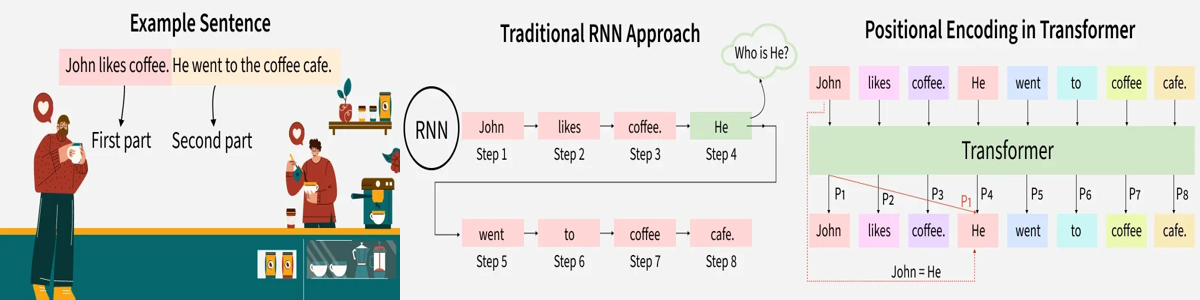

In [ ]:
from PIL import Image
from IPython.display import display

image1 = Image.open("/content/example_sentence.webp")
image2 = Image.open("/content/traditional_rnn_approach2.webp")
image3 = Image.open("/content/positional_encoding_in_transformer.webp")


size = (400, 300)

image1 = image1.resize(size)
image2 = image2.resize(size)
image3 = image3.resize(size)


combined = Image.new("RGB", (1200, 300), "white")


combined.paste(image1, (0, 0))
combined.paste(image2, (400, 0))
combined.paste(image3, (800, 0))

display(combined)

# 🔷 Positional Encoding — বিস্তারিত ধারণা

## 1️⃣ Positional Encoding কী?

**Positional Encoding** হলো এমন একটা টেকনিক, যার মাধ্যমে প্রতিটা token/word-এর **sequence-এ অবস্থান (position)** সম্পর্কিত তথ্য input embedding-এর সাথে যোগ করে দেওয়া হয়।

এটা দরকার হয় কারণ — Self-Attention mechanism সব word **একসাথে (parallel-ly)** প্রসেস করে, ফলে স্বাভাবিকভাবেই এটা জানে না কোন word sentence-এ কোথায় (কত নম্বর position-এ) আছে। Positional Encoding এই ঘাটতি পূরণ করে।

---

## 2️⃣ কেন Positional Encoding দরকার হলো? (মূল সমস্যা)

### 🔴 Self-Attention-এর একটা লুকানো সমস্যা: Permutation Invariance

RNN/LSTM word গুলো **এক এক করে ক্রমানুসারে** পড়তো, তাই position তথ্য স্বাভাবিকভাবেই তার structure-এর মধ্যেই ছিল। কিন্তু Self-Attention পুরো sentence **একসাথে matrix multiplication** দিয়ে প্রসেস করে — তার কাছে "How are you" আর "you are How" — এই দুইটা **সম্পূর্ণ একই রকম** মনে হবে, যদি position তথ্য আলাদা করে যোগ না করা হয়!

> উদাহরণ: *"The cat sat on the mat"* আর *"The mat sat on the cat"* — দুইটা sentence-এ একই word আছে, কিন্তু অর্থ সম্পূর্ণ ভিন্ন। শুধু Self-Attention (position ছাড়া) এই দুইটাকে **আলাদা করতে পারবে না**।

### ✅ সমাধান
তাই প্রতিটা word embedding-এর সাথে তার **position অনুযায়ী একটা ইউনিক vector** যোগ করে দেওয়া হয় — যাতে model বুঝতে পারে কোন word কোথায় বসে আছে।

---

## 3️⃣ Positional Encoding কীভাবে কাজ করে? (Sinusoidal Method)

Transformer paper-এ **sine এবং cosine function** ব্যবহার করে positional encoding তৈরি করা হয়। এই পদ্ধতি বেছে নেওয়ার কারণ — sine/cosine wave **smooth ও periodic (পর্যাবৃত্ত)**, ফলে এটা:
- যেকোনো length-এর sequence-এর জন্য generalize করতে পারে
- কাছাকাছি position-গুলোর মধ্যে smooth transition বজায় রাখে

### 🔑 Formula

প্রতিটা position ($pos$) এবং dimension ($i$)-এর জন্য:

**Even index (juju dimension):**
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

**Odd index (বিজোড় dimension):**
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

যেখানে:
- $pos$ = sequence-এ token-এর position (0 থেকে শুরু)
- $i$ = dimension-এর index
- $d_{model}$ = embedding dimension (যেমন 512)

> 🔑 **কেন sine আর cosine দুটোই ব্যবহার হয়?** Even dimension-এ sine, odd dimension-এ cosine — এই combination দিয়ে প্রতিটা position-এর জন্য একটা **unique কিন্তু smooth "pattern"** তৈরি হয়, যা model-কে relative position (একটা word আরেকটা থেকে কত দূরে) বুঝতেও সাহায্য করে।

---

## 4️⃣ সংখ্যা দিয়ে উদাহরণ (৪-dimensional embedding)

ধরি sentence: **"The cat sat on the mat"**, আর embedding dimension $d_{model} = 4$।

### Position 1 ("The")-এর জন্য:
$$PE(1) = \left[\sin\left(\frac{1}{10000^{0/4}}\right),\ \cos\left(\frac{1}{10000^{0/4}}\right),\ \sin\left(\frac{1}{10000^{2/4}}\right),\ \cos\left(\frac{1}{10000^{2/4}}\right)\right]$$

### Position 2 ("cat")-এর জন্য:
$$PE(2) = \left[\sin\left(\frac{2}{10000^{0/4}}\right),\ \cos\left(\frac{2}{10000^{0/4}}\right),\ \sin\left(\frac{2}{10000^{2/4}}\right),\ \cos\left(\frac{2}{10000^{2/4}}\right)\right]$$

এভাবে **Position 6 ("mat")** পর্যন্ত প্রতিটা token-এর জন্য একটা করে ৪-dimensional positional vector বের করা হয়।

### 🔹 এরপর কী হয়?
এই positional encoding vector-কে সংশ্লিষ্ট word-এর **embedding vector-এর সাথে element-wise যোগ (addition)** করে দেওয়া হয়:

$$\text{Final Input} = \text{Word Embedding} + \text{Positional Encoding}$$

ফলে প্রতিটা token-এর চূড়ান্ত representation-এ **এখন দুইটা তথ্যই থাকে**:
1. Word-টার **semantic meaning** (embedding থেকে)
2. Word-টার **position** (positional encoding থেকে)

---

## 5️⃣ কেন এই Exponential Term ($10000^{2i/d_{model}}$) ব্যবহার হয়?

Formula-এর ভেতরে থাকা এই অংশটা মূলত **প্রতিটা dimension-এর জন্য sine wave-এর frequency (কম্পাঙ্ক) আলাদা করে দেয়**:

- **নিচু dimension** (i ছোট) → sine wave-এর **frequency বেশি** (দ্রুত পরিবর্তন হয়) → কাছাকাছি position-গুলো আলাদা করতে ভালো কাজ করে
- **উঁচু dimension** (i বড়) → sine wave-এর **frequency কম** (ধীরে পরিবর্তন হয়) → দূরের position-গুলো আলাদা করতে ভালো কাজ করে

> এভাবে বিভিন্ন frequency-এর wave একসাথে মিশিয়ে একটা **সমৃদ্ধ, multi-scale positional signature** তৈরি হয় — অনেকটা বাইনারি নাম্বার সিস্টেমের মতো, যেখানে বিভিন্ন bit বিভিন্ন frequency-তে পরিবর্তিত হয়ে একটা ইউনিক নাম্বার তৈরি করে।

---

## 6️⃣ Python Implementation (কীভাবে বাস্তবে হিসাব হয়)

```python
import numpy as np
import tensorflow as tf

def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000, (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model)
    )
    
    # even index -> sine
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    # odd index -> cosine
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)

position = 50      # sequence length
d_model = 512       # embedding dimension
pos_encoding = positional_encoding(position, d_model)

print("Shape:", pos_encoding.shape)  # (1, 50, 512)
```

---

## 7️⃣ Positional Encoding-এর গুরুত্ব (Why It Matters)

| গুরুত্ব | ব্যাখ্যা |
|---|---|
| **Contextual Understanding** | ভাষায় word-এর অর্থ position-এর উপরও নির্ভর করে, এটা বুঝতে সাহায্য করে |
| **Better Generalization** | বিভিন্ন length-এর sequence handle করতে পারে (document summarization, QA-এর মতো task-এ কাজে লাগে) |
| **Symmetry সমস্যা প্রতিরোধ** | Positional encoding ছাড়া model প্রতিটা token-কে "একই রকম" মনে করতো (order বোঝাই যেতো না); এটা প্রতিটা position-কে আলাদা করে চিনতে সাহায্য করে, ফলে long-range dependency ভালোভাবে ধরা যায় |

---

## 8️⃣ Positional Encoding-এর সীমাবদ্ধতা (Limitations)

- ⚠️ **Fixed Length**: Original Transformer-এ positional encoding একটা নির্দিষ্ট maximum length পর্যন্ত (যেমন 512 token) কাজ করার জন্য ডিজাইন করা — এর বেশি লম্বা sequence-এ সমস্যা হতে পারে (এই সমস্যা সমাধানে পরে **Relative Positional Encoding**-এর মতো variation তৈরি হয়েছে)
- ⚠️ **Dynamic/Relative Position Handling সীমিত**: কিছু task-এ (যেমন translation-এ যেখানে sentence structure পুরোপুরি পাল্টে যেতে পারে) more flexible, relative positional encoding দরকার হতে পারে — original sinusoidal method সবসময় সেটা পুরোপুরি দিতে পারে না

---

## 9️⃣ Positional Encoding-এর Applications

| ক্ষেত্র | ব্যবহার |
|---|---|
| **Machine Translation** | সঠিক word order বজায় রাখতে সাহায্য করে |
| **Text Generation (GPT-এর মতো)** | Grammatically ও semantically সঠিক ক্রমে টেক্সট generate করতে |
| **Time Series Forecasting** | সময়ের সাথে data-এর pattern শিখতে |
| **Speech Recognition** | phoneme/word-এর সময়ানুক্রমিক (temporal) ক্রম বুঝতে |
| **Vision Transformer (ViT)** | ছবির বিভিন্ন patch-এর মধ্যে spatial সম্পর্ক বুঝতে |

---



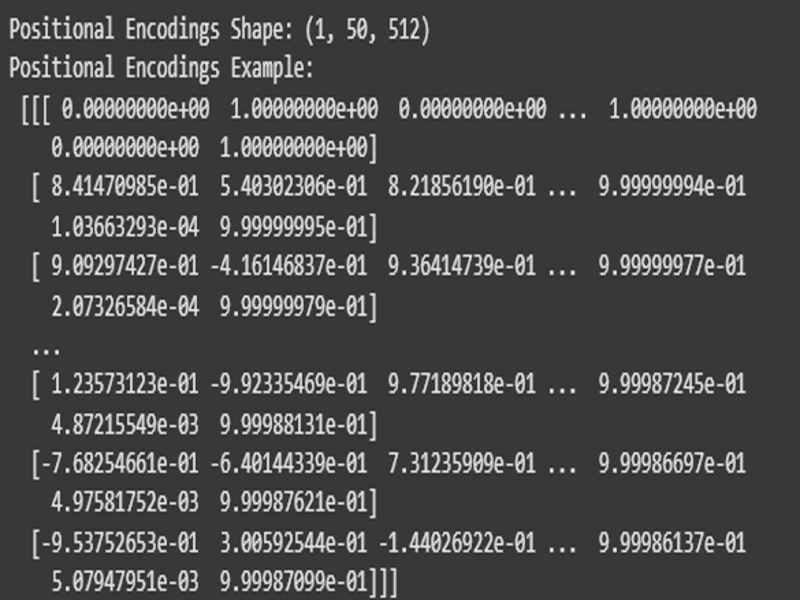

In [ ]:
from PIL import Image
from IPython.display import display

image = Image.open("/content/encoding-output.png")

image = image.resize((800, 600))

display(image)

# 🔷 Positional Encoding Output — কী বোঝাচ্ছে এই সংখ্যাগুলো?

## 1️⃣ প্রথমে Shape বোঝা যাক: `(1, 50, 512)`

এই output-টা একটা **3D array (tensor)**। এর প্রতিটা dimension-এর মানে:

| Dimension | মান | কী বোঝায় |
|---|---|---|
| **1st** | 1 | Batch size (একবারে একটাই sentence প্রসেস হচ্ছে) |
| **2nd** | 50 | Sequence length — অর্থাৎ আমরা **৫০টা position**-এর জন্য encoding তৈরি করেছি (position 0 থেকে 49) |
| **3rd** | 512 | Embedding dimension ($d_{model}$) — প্রতিটা position-এর জন্য **512টা সংখ্যার একটা vector** |

> 🔑 সহজ ভাষায়: এই array-টা হলো — "৫০টা possible position-এর প্রত্যেকটার জন্য, একটা করে ৫১২-dimensional ইউনিক 'পরিচয়পত্র (fingerprint)' vector"।

---

## 2️⃣ প্রতিটা Row আসলে কী? (Row = একটা Position)

Output-এর প্রতিটা row একটা নির্দিষ্ট **position**-এর জন্য positional encoding vector। তুমি output-এ যা দেখছো:

Row 0 (Position 0): [0.000, 1.000, 0.000, ... , 1.000, 0.000, 1.000]

Row 1 (Position 1): [0.841, 0.540, 0.821, ... , 0.999, 1.036, 0.999]

Row 2 (Position 2): [0.909, -0.416, 0.936, ... , 0.999, 0.207, 0.999]


### 🔑 লক্ষ্য করার বিষয়:
- **Position 0**-এর encoding সবসময় একটা নির্দিষ্ট pattern দিয়ে শুরু হয় (sin(0)=0, cos(0)=1 — তাই প্রথম row-এ 0, 1, 0, 1... এই প্যাটার্ন দেখা যায়)
- **Position 1** এর values সম্পূর্ণ আলাদা — কারণ sine/cosine function-এ $pos=1$ বসিয়ে হিসাব হয়েছে
- **Position 2**-এর values আবার আলাদা

> মানে ৫০টা row-ই একে অপরের থেকে **আলাদা (unique)**, কারণ প্রতিটা position-এর জন্য formula-তে ভিন্ন $pos$ মান বসানো হয়েছে।

---

## 3️⃣ একটা ছোট বাস্তব Example দিয়ে বুঝি

ধরো, sentence: **"I love AI"** — এখানে ৩টা word, position হবে 0, 1, 2 (0-indexed)।

যদি এই output থেকে আমরা শুধু প্রথম ৩টা row নিই:

| Word | Position | Positional Encoding (প্রথম কয়েকটা মান) |
|---|---|---|
| "I" | 0 | `[0.000, 1.000, 0.000, ..., 1.000]` |
| "love" | 1 | `[0.841, 0.540, 0.821, ..., 0.999]` |
| "AI" | 2 | `[0.909, -0.416, 0.936, ..., 0.999]` |

এখন এই তিনটা vector-কে সংশ্লিষ্ট word-এর **embedding vector-এর সাথে element-wise যোগ** করা হবে:

$$\text{Final Input}_{\text{"I"}} = \text{Embedding}_{\text{"I"}} + [0.000, 1.000, 0.000, ...]$$
$$\text{Final Input}_{\text{"love"}} = \text{Embedding}_{\text{"love"}} + [0.841, 0.540, 0.821, ...]$$
$$\text{Final Input}_{\text{"AI"}} = \text{Embedding}_{\text{"AI"}} + [0.909, -0.416, 0.936, ...]$$

> ✅ এখন "I", "love", "AI" — প্রতিটা word-এর representation-এ তার **নিজস্ব semantic meaning** (embedding থেকে) এবং **নিজস্ব position তথ্য** (positional encoding থেকে) — দুটোই মিশে আছে।

---

## 4️⃣ এই Output Attention Mechanism-এ কী ভূমিকা রাখে?

এখন সবচেয়ে গুরুত্বপূর্ণ প্রশ্ন — এই positional encoding যোগ করা vector গুলো Self-Attention-এ কীভাবে কাজ করে?

মনে করো, আমরা আগে যে Self-Attention শিখেছিলাম (Q, K, V দিয়ে), সেখানে input হিসেবে যে $X$ (word embedding) ব্যবহার হয়েছিল — বাস্তবে সেটা এখন **শুধু embedding না**, বরং:

$$X_{\text{final}} = \text{Word Embedding} + \text{Positional Encoding}$$

### 🔑 এই যোগফলটাই Q, K, V তৈরির জন্য ব্যবহার হয়:

$$Q = X_{\text{final}} \cdot W_Q, \quad K = X_{\text{final}} \cdot W_K, \quad V = X_{\text{final}} \cdot W_V$$

### এর ফলে কী হয়?
যেহেতু $X_{\text{final}}$-এর মধ্যে এখন position তথ্যও মিশে আছে, তাই যখন Attention Score ($QK^T$) হিসাব হয়, তখন সেটা শুধু **"এই দুই word semantically কতটা কাছাকাছি"** সেটাই না, বরং সাথে সাথে **"এই দুই word sentence-এ কোথায় অবস্থিত (কত দূরে বা কাছে)"** — এই তথ্যও পরোক্ষভাবে হিসাবের মধ্যে চলে আসে।

### 🎯 Concrete উদাহরণ:
ধরো sentence: *"The cat sat on the mat"* আর *"The mat sat on the cat"*

- এই দুই sentence-এ **একই word** আছে, কিন্তু **ভিন্ন position**-এ
- Positional Encoding ছাড়া: "cat" শব্দটার representation দুই sentence-এই **হুবহু একই** হতো → Attention Score-ও একই হতো → model দুই sentence-এর পার্থক্য বুঝতেই পারতো না
- Positional Encoding **সহ**: "cat" শব্দটা প্রথম sentence-এ position 1-এ, দ্বিতীয় sentence-এ position 5-এ — তাই তার final vector আলাদা হবে → Attention Score-ও আলাদা হবে → model বুঝবে দুই sentence-এর অর্থ ভিন্ন

---

## 📌 পুরো Flow-টা এক নজরে

Positional Encoding Array (1, 50, 512)

↓ (প্রতিটা position-এর জন্য একটা 512-dim vector আছে)


Sentence-এর প্রতিটা word তার position অনুযায়ী
সংশ্লিষ্ট row/vector "তুলে নেয়"

↓

Word Embedding + Positional Encoding (element-wise addition)

↓

X_final (এখন meaning + position দুটোই আছে)

↓

Q = X_final × W_Q, K = X_final × W_K, V = X_final × W_V

↓

Attention Score = QKᵀ (এখন position-aware!)

↓

Softmax → Weighted Sum of V

↓

Context + Position দুটোই বিবেচনা করা Output



---

## 🔑 সংক্ষেপে (Summary)

> এই output-টা আসলে **৫০টা position-এর জন্য প্রি-ক্যালকুলেটেড, ইউনিক ৫১২-dimensional vector-এর একটা লুকআপ টেবিল**। যখন কোনো sentence আসে, প্রতিটা word তার position অনুযায়ী এই টেবিল থেকে সংশ্লিষ্ট vector নেয় এবং নিজের word embedding-এর সাথে যোগ করে নেয়। এর ফলে, Self-Attention যখন Q, K, V হিসাব করে Attention Score বের করে, তখন সেটা শুধু word-গুলোর **semantic সম্পর্ক** না, বরং তাদের **অবস্থানগত সম্পর্কও (positional relationship)** বিবেচনা করে — যার ফলে model "The cat sat on the mat" আর "The mat sat on the cat"-এর মতো একই word কিন্তু ভিন্ন order-এর sentence-গুলোর মধ্যে পার্থক্য করতে পারে।

# 🔷 Position-wise Feed-Forward Network (FFN) — বিস্তারিত ধারণা

## 1️⃣ Position-wise Feed-Forward Network কী?

**Feed-Forward Network (FFN)** হলো Encoder ও Decoder-এর প্রতিটা layer-এ Multi-Head Attention-এর পরে থাকা একটা **সাধারণ, ছোট Neural Network** — যেটা প্রতিটা position (প্রতিটা word/token)-এর representation-কে **আলাদা আলাদাভাবে (independently)** আরও প্রসেস ও সমৃদ্ধ করে।

"Position-wise" শব্দটার মানে হলো — এই একই FFN sentence-এর **প্রতিটা position (word)-এর উপর আলাদা আলাদাভাবে**, কিন্তু **একই weight** দিয়ে প্রয়োগ করা হয়।

---

## 2️⃣ FFN কেন দরকার হলো?

### 🔴 Self-Attention একা যথেষ্ট নয় কেন?

Multi-Head Attention-এর কাজ হলো **word-গুলোর মধ্যে সম্পর্ক (relationship) বের করা** — এটা মূলত একটা **linear operation** (matrix multiplication + weighted sum)। কিন্তু:

- Attention শুধু **information gathering/mixing** করে (কোন word থেকে কতটা তথ্য নিতে হবে সেটা ঠিক করে)
- এটা প্রতিটা word-এর representation-কে **individually, non-linear ভাবে transform/refine** করতে পারে না

### ✅ FFN-এর ভূমিকা
Attention থেকে পাওয়া output-কে FFN আরও **গভীরভাবে প্রসেস** করে:
- **Non-linearity** যোগ করে (activation function দিয়ে) — যা model-কে জটিল (complex), non-linear pattern শিখতে সাহায্য করে
- প্রতিটা word-এর representation-কে **individually "চিন্তা করার" সুযোগ** দেয় — Attention-এ যেই তথ্য অন্য word থেকে সংগ্রহ করা হয়েছে, সেটাকে এখন processing/refine করার একটা ধাপ

> 🔑 সহজ Analogy: **Attention layer** হলো "তথ্য সংগ্রহ করার" ধাপ (কে কার কাছ থেকে কী তথ্য নিবে) — আর **FFN** হলো সেই সংগৃহীত তথ্য নিয়ে "individually চিন্তা-ভাবনা করে বোঝার" ধাপ।

---

## 3️⃣ FFN-এর গঠন (Architecture) এবং Formula

Position-wise FFN আসলে দুইটা **Linear (Fully Connected) layer**, মাঝে একটা **non-linear activation function (ReLU)** সহ:

$$\text{FFN}(x) = \max(0,\ xW_1 + b_1)\,W_2 + b_2$$

### ধাপে ধাপে ভাঙলে:

| ধাপ | কাজ |
|---|---|
| **Linear Layer 1** | $x W_1 + b_1$ — input dimension ($d_{model}$, যেমন 512) থেকে একটা **বড় hidden dimension**-এ ($d_{ff}$, যেমন 2048) নিয়ে যাওয়া |
| **ReLU Activation** | $\max(0, \cdot)$ — negative মানগুলোকে 0 করে দেওয়া, non-linearity যোগ করা |
| **Linear Layer 2** | $(\cdot)W_2 + b_2$ — আবার hidden dimension (2048) থেকে original dimension ($d_{model}$, 512)-এ ফিরিয়ে আনা |

### 🔑 Dimension উদাহরণ (Original Transformer Paper অনুযায়ী):
- Input dimension ($d_{model}$) = **512**
- Hidden dimension ($d_{ff}$) = **2048** (৪ গুণ বড়!)
- Output dimension = আবার **512** (যাতে পরের layer-এ ঠিকভাবে যেতে পারে)

Input (512) → Linear₁ → Hidden (2048) → ReLU → Linear₂ → Output (512)

---

## 4️⃣ কেন Dimension প্রথমে বড় (2048) করে আবার ছোট (512) করা হয়?

এটা একটা গুরুত্বপূর্ণ design choice:

- **Expand করা (512 → 2048)**: বেশি dimension মানে model-এর কাছে representation প্রসেস করার জন্য **বেশি "স্পেস"/capacity** থাকে — এতে জটিল pattern ধরার সুযোগ বাড়ে (অনেকটা একটা সমস্যাকে বড় জায়গায় ছড়িয়ে চিন্তা করার মতো)
- **আবার Compress করা (2048 → 512)**: পরের layer-এর সাথে dimension মিলাতে, এবং শুধু গুরুত্বপূর্ণ তথ্যটুকু বের করে আনতে (একটা bottleneck-এর মতো কাজ করে, যা useful feature আলাদা করতে সাহায্য করে)

---

## 5️⃣ কেন "Position-wise"? (প্রতিটা Position আলাদাভাবে, কিন্তু একই Weight দিয়ে)

এই বিষয়টা একটু confusing লাগতে পারে, তাই স্পষ্ট করে বুঝি:

### 🔑 দুইটা গুরুত্বপূর্ণ বিষয়:

1. **আলাদাভাবে প্রয়োগ (Independently Applied)**: Sentence-এর প্রতিটা word/position-এর representation-এর উপর FFN **আলাদাভাবে** প্রয়োগ হয় — একটা word-এর FFN calculation আরেকটা word-এর calculation-কে প্রভাবিত করে না (Attention-এর মতো word-গুলোর মধ্যে interaction হয় না)

2. **কিন্তু Weight একই (Same Weights across positions)**: $W_1, b_1, W_2, b_2$ — এই একই weight matrix **sentence-এর সব position-এর জন্য ব্যবহার হয়**। মানে "I", "love", "AI" — এই তিনটা word-ই **একই FFN function** দিয়ে প্রসেস হয়, কিন্তু প্রতিটার input আলাদা হওয়ায় output-ও আলাদা হয়।

> 🔑 Analogy: কল্পনা করো একটা **factory machine** — একই মেশিন (একই weight) প্রতিটা পণ্য (প্রতিটা word)-এর উপর আলাদা আলাদাভাবে কাজ করছে (একটা পণ্য আরেকটা পণ্যের প্রসেসিং-কে প্রভাবিত করছে না), কিন্তু মেশিনটা (function) সবসময় একই।

### এর সুবিধা কী?
- **Parameter efficiency**: প্রতিটা position-এর জন্য আলাদা weight শেখার দরকার নেই — একই weight পুরো sentence জুড়ে reuse হয়, ফলে model-এর parameter সংখ্যা অনেক কম থাকে
- **Consistency**: প্রতিটা word একই "rule" দিয়ে transform হয়, ফলে model বিভিন্ন length-এর sentence-এও ভালোভাবে generalize করতে পারে

---

## 6️⃣ FFN কোথায় বসে (Architecture-এ Position)

আগের diagram অনুযায়ী মনে করিয়ে দিই — প্রতিটা Encoder/Decoder layer-এ FFN-এর অবস্থান:

Input

↓

Multi-Head Attention

↓

Add & Norm ← (Residual connection + LayerNorm)

↓

Feed Forward Network (FFN) ← এখানেই আমরা এখন আছি

↓

Add & Norm ← (আবার Residual + LayerNorm)

↓

Output (পরের layer-এ যায়)


FFN সবসময় **Attention layer-এর পরে**, এবং তার নিজের চারপাশেও **Add & Norm (Residual Connection)** থাকে — অর্থাৎ:

$$\text{Output} = \text{LayerNorm}(x + \text{FFN}(x))$$

---

## 7️⃣ Attention আর FFN-এর ভূমিকার পার্থক্য (একসাথে বোঝা)

| বিষয় | Multi-Head Attention | Feed-Forward Network |
|---|---|---|
| **মূল কাজ** | Word-গুলোর মধ্যে **সম্পর্ক/তথ্য আদান-প্রদান** (communication) | প্রতিটা word-এর representation **individually প্রসেস/refine** করা |
| **Interaction** | Word-গুলো একে অপরের সাথে interact করে (cross-word) | প্রতিটা position স্বাধীনভাবে কাজ করে (no cross-word interaction) |
| **Linearity** | মূলত linear (weighted sum) | Non-linear (ReLU activation যোগ করে) |
| **তুলনা** | "কে কার কথা শুনবে" ঠিক করা | সংগৃহীত তথ্য নিয়ে "গভীরভাবে চিন্তা করা" |

> 🔑 এই দুইটা component **একসাথে মিলে** প্রতিটা Encoder/Decoder layer-কে শক্তিশালী করে তোলে — Attention "communication" করে, FFN "computation/refinement" করে।

---

## 📌 পুরো প্রসেসটা এক নজরে

Attention Output (512-dim, প্রতিটা word-এর জন্য)

↓

┌─────────────────────────────┐

│ Linear Layer 1 (512 → 2048)│
│ ↓ │
│ ReLU │
│ ↓ │
│ Linear Layer 2 (2048 → 512)│

└─────────────────────────────┘

↓

(প্রতিটা word-এর জন্য আলাদাভাবে, একই weight দিয়ে)
Refined, Non-linear Representation

↓

Add & Norm (Residual + LayerNorm)

↓

পরের Layer-এ যায়



---

## 🔑 সংক্ষেপে (Summary)

> **Position-wise Feed-Forward Network** হলো একটা দুই-স্তরের (two-layer) সাধারণ neural network, যা প্রতিটা word/position-এর Attention output-কে **আলাদাভাবে কিন্তু একই weight দিয়ে** আরও প্রসেস করে। এটা দরকার হয় কারণ Attention শুধু word-গুলোর মধ্যে **তথ্য আদান-প্রদান (linear combination)** করে, কিন্তু FFN সেই তথ্যকে **non-linear activation (ReLU)** দিয়ে গভীরভাবে transform করে — যা model-কে আরও জটিল pattern শিখতে সক্ষম করে। এটা প্রথমে dimension বড় করে (512→2048) বেশি "processing space" দেয়, তারপর আবার ছোট করে (2048→512) গুরুত্বপূর্ণ তথ্য বের করে আনে, এবং সবশেষে Residual Connection ও Layer Normalization দিয়ে stable রাখা হয়।

# 🔷 Add & Norm — Residual Connections এবং Layer Normalization

## 1️⃣ Add & Norm কী?

**Add & Norm** আসলে দুইটা আলাদা কিন্তু একসাথে ব্যবহৃত টেকনিকের সমন্বয়:

1. **Add** = **Residual Connection** (Skip Connection) — sublayer-এর input-কে তার output-এর সাথে সরাসরি যোগ করে দেওয়া
2. **Norm** = **Layer Normalization** — যোগফলকে normalize (স্থিতিশীল) করা

$$\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$

এখানে **Sublayer** হতে পারে Multi-Head Attention অথবা Feed-Forward Network — Encoder/Decoder-এর প্রতিটা sublayer-এর পরেই এই Add & Norm বসানো থাকে (diagram-এ দেখেছিলে, প্রতিটা attention/FFN block-এর ঠিক পরেই "Add & Norm" আছে)।

---

## 2️⃣ প্রথমে বুঝি: Residual Connection (Add) কেন দরকার?

### 🔴 সমস্যা: Deep Network Training-এর কষ্ট

Transformer-এ Encoder ও Decoder-এ অনেকগুলো layer একটার উপর একটা স্তুপ করা থাকে (৬টা বা তার বেশি, আর প্রতিটা layer-এর ভেতরেও একাধিক sublayer থাকে)। Network যত **গভীর (deep)** হয়, ততই দুইটা সমস্যা দেখা দেয়:

1. **Vanishing Gradient**: Backpropagation-এর সময় gradient বহু layer পার হয়ে আসতে আসতে **ক্রমশ ছোট হয়ে যায় (প্রায় শূন্য)** — ফলে শুরুর দিকের layer-গুলো ঠিকভাবে শিখতে পারে না
2. **Degradation Problem**: গভীর network কখনো কখনো **অগভীর network-এর চেয়েও খারাপ** performance দেয় — কারণ প্রতিটা layer-কে সঠিকভাবে "কিছু শেখা" কঠিন হয়ে পড়ে যদি সে শূন্য থেকে সবকিছু শিখতে বাধ্য হয়

### ✅ সমাধান: Residual Connection (Skip Connection)

Residual Connection-এর ধারণা খুব সহজ — sublayer-এর **input-কে সরাসরি তার output-এর সাথে যোগ করে দাও**:

$$\text{Output} = x + \text{Sublayer}(x)$$

### 🔑 এর পেছনের যুক্তি (Intuition)

Sublayer-কে এখন পুরো transformation শেখার বদলে শুধু **"residual" (অতিরিক্ত পরিবর্তন/correction)** শিখতে হয়:

> **Analogy**: ধরো তুমি একটা essay লিখছো। Residual Connection ছাড়া, প্রতিটা editor-কে পুরো essay-টা **নতুন করে লিখতে হতো**। কিন্তু Residual Connection থাকলে, প্রতিটা editor শুধু বলে দেয় — "মূল essay-টা ঠিক রাখো, শুধু এইটুকু **change/improvement** যোগ করো" — এটা অনেক সহজ কাজ, আর মূল essay (original information)-ও হারিয়ে যায় না।

### 🔑 Gradient Flow-এর দিক থেকে সুবিধা
যখন আমরা $x + \text{Sublayer}(x)$ থেকে derivative নিই:

$$\frac{\partial \text{Output}}{\partial x} = 1 + \frac{\partial \text{Sublayer}(x)}{\partial x}$$

এখানে সবসময় একটা **"+1" (identity path)** থাকে — এর মানে gradient-এর একটা অংশ সবসময় **সরাসরি, বাধাহীনভাবে** পেছনের দিকে (earlier layers-এ) প্রবাহিত হতে পারে, Sublayer যতই জটিল হোক না কেন। এতে vanishing gradient সমস্যা অনেকটাই কমে যায়, আর অনেক গভীর network-ও ভালোভাবে train করা যায় (এই ধারণাটা মূলত ResNet থেকে Transformer-এ নেওয়া হয়েছে)।

---

## 3️⃣ এবার বুঝি: Layer Normalization (Norm) কেন দরকার?

### 🔴 সমস্যা: Layer-এর মধ্য দিয়ে যেতে যেতে Value-এর Scale এলোমেলো হয়ে যাওয়া

Network-এর প্রতিটা layer পার হওয়ার সাথে সাথে output value-গুলোর **scale (magnitude) এবং distribution** পরিবর্তিত হতে থাকে — কখনো খুব বড়, কখনো খুব ছোট হয়ে যেতে পারে। এর ফলে:
- Training **অস্থির (unstable)** হয়ে যায়
- Model শিখতে বেশি সময় নেয়, অথবা ঠিকভাবে converge করে না

### ✅ সমাধান: Layer Normalization

Layer Normalization প্রতিটা sample-এর (এখানে প্রতিটা word/token-এর) **feature dimension জুড়ে** (across the $d_{model}$ dimension) values-কে normalize করে — যাতে সেগুলোর **mean ≈ 0** এবং **variance ≈ 1** হয়:

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

যেখানে:
- $\mu$ = ওই token-এর সব feature-এর mean (গড়)
- $\sigma^2$ = variance
- $\epsilon$ = খুব ছোট একটা সংখ্যা (division by zero এড়াতে)
- $\gamma, \beta$ = **learnable parameters** — normalize করার পরেও model যদি চায় scale/shift করতে পারবে (flexibility রাখার জন্য)

### 🔑 Batch Normalization থেকে Layer Normalization কেন আলাদা?

| | Batch Normalization | Layer Normalization |
|---|---|---|
| **Normalize করে কীসের উপর** | একই feature-এর জন্য পুরো **batch** জুড়ে | একই token-এর **সব feature** জুড়ে |
| **Sequence data-তে সমস্যা** | Batch-এর প্রতিটা sentence-এর length আলাদা হতে পারে, তাই batch-wise normalize করা কঠিন ও অস্থির | প্রতিটা token independently normalize হয়, sequence length-এর উপর নির্ভর করে না |
| **Transformer-এ ব্যবহার** | ব্যবহার হয় না | **এটাই ব্যবহার হয়** |

> 🔑 এই জন্যই Transformer-এ Batch Norm না নিয়ে **Layer Norm** ব্যবহার করা হয় — কারণ NLP-তে sentence length ভিন্ন ভিন্ন হয়, আর Layer Norm প্রতিটা token-কে independently normalize করে বলে batch size বা sequence length নিয়ে কোনো সমস্যা হয় না।

---

## 4️⃣ Add আর Norm একসাথে কীভাবে কাজ করে?

সম্পূর্ণ প্রসেসটা:

$$\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$

### ধাপে ধাপে:
1. **Input** $x$ sublayer-এ (Attention বা FFN) যায়
2. Sublayer output $\text{Sublayer}(x)$ তৈরি করে
3. **Add**: Original input $x$-কে সেই output-এর সাথে যোগ করা হয় → $x + \text{Sublayer}(x)$
4. **Norm**: এই যোগফলকে Layer Normalization দিয়ে স্থিতিশীল করা হয়

---

## 5️⃣ Diagram-এ কোথায় কোথায় Add & Norm আছে?

আগের architecture diagram অনুযায়ী, প্রতিটা Encoder layer-এ **২ বার**, প্রতিটা Decoder layer-এ **৩ বার** Add & Norm ব্যবহার হয়:

**Encoder-এ:**

Input

↓

Multi-Head Attention

↓

Add & Norm ① ← x + Attention(x), তারপর normalize

↓

Feed Forward

↓

Add & Norm ② ← x + FFN(x), তারপর normalize


**Decoder-এ:**

Input

↓

Masked Multi-Head Attention

↓

Add & Norm ①

↓

Encoder-Decoder (Cross) Attention

↓

Add & Norm ②

↓

Feed Forward

↓

Add & Norm ③


---

## 6️⃣ ছোট Numerical উদাহরণ (Intuition-এর জন্য)

ধরি একটা word-এর input vector, $d_{model} = 4$:
$$x = [1.0,\ 2.0,\ 3.0,\ 4.0]$$

Attention sublayer-এর পর output ধরি:
$$\text{Sublayer}(x) = [0.1,\ -0.2,\ 0.3,\ 0.5]$$

### Step 1: Add (Residual Connection)
$$x + \text{Sublayer}(x) = [1.1,\ 1.8,\ 3.3,\ 4.5]$$

### Step 2: Normalize
এই vector-এর:
- Mean $\mu = \frac{1.1+1.8+3.3+4.5}{4} = 2.675$
- Variance হিসাব করে standard deviation বের করা হয়

তারপর প্রতিটা মান থেকে mean বিয়োগ করে standard deviation দিয়ে ভাগ করা হয় → ফলাফল একটা normalized vector, যার mean প্রায় 0, variance প্রায় 1 হবে — তারপর $\gamma, \beta$ দিয়ে scale/shift করা হয়।

> 🔑 এভাবে প্রতিটা word-এর representation-এর scale সবসময় একটা নিয়ন্ত্রিত (controlled) range-এ থাকে, layer যতই গভীর হোক না কেন।

---

## 7️⃣ Add & Norm-এর সুবিধা (এক নজরে)

| সুবিধা | কীভাবে আসে |
|---|---|
| **Vanishing Gradient কমায়** | Residual connection-এর identity path দিয়ে gradient সরাসরি প্রবাহিত হয় |
| **Deep Network Training সহজ করে** | Sublayer-কে পুরো transformation না শিখে শুধু "correction/residual" শিখতে হয় |
| **Training Stability** | Layer Normalization value-গুলোকে নিয়ন্ত্রিত range-এ রাখে, training দ্রুত ও স্থিতিশীল হয় |
| **Original Information সংরক্ষণ** | Residual connection-এর কারণে input-এর মূল তথ্য কখনো সম্পূর্ণ হারিয়ে যায় না |
| **Sequence Length-independent** | Layer Norm batch/sequence length নিয়ে সমস্যা করে না (Batch Norm-এর বিপরীতে) |

---

## 🔑 সংক্ষেপে (Summary)

> **Add & Norm** দুইটা গুরুত্বপূর্ণ টেকনিকের সমন্বয়: **Residual Connection (Add)** sublayer-এর input-কে output-এর সাথে সরাসরি যোগ করে দেয়, যাতে gradient বাধাহীনভাবে প্রবাহিত হতে পারে এবং deep network-এও training কার্যকর থাকে (vanishing gradient সমস্যা কমে)। **Layer Normalization (Norm)** প্রতিটা token-এর feature values-কে normalize করে (mean≈0, variance≈1), যাতে layer-এর পর layer পার হতে গিয়ে value-এর scale এলোমেলো না হয়ে যায় এবং training স্থিতিশীল ও দ্রুত হয়। এই দুইটা মিলে $\text{LayerNorm}(x + \text{Sublayer}(x))$ ফর্মুলা তৈরি করে, যা প্রতিটা Attention ও FFN sublayer-এর পরে ব্যবহার করে Transformer-এর মতো গভীর architecture-কেও efficiently train করা সম্ভব করে তোলে।

# 🔷 Softmax Layer for Output Prediction — শেষ ধাপ ব্যাখ্যা

## 1️⃣ Decoder-এর শেষে কী ঘটে? (Recap)

Decoder-এর সবগুলো layer (Masked Attention → Cross-Attention → FFN → Add & Norm) পার হয়ে যাওয়ার পর, আমরা পাই একটা vector — যেটা এখনো **শুধুই সংখ্যা**, কোনো word না। এই vector-কে **actual word prediction**-এ রূপান্তর করার জন্যই এই শেষ ধাপ দরকার হয়।

---

## 2️⃣ Linear Layer — কেন এবং কী করে?

### 🔴 সমস্যা
Decoder-এর output vector-এর dimension হলো $d_{model}$ (যেমন 512) — কিন্তু আমাদের vocabulary-তে হয়তো **৫০,০০০+ শব্দ** আছে। আমাদের জানতে হবে — এই ৫০,০০০ শব্দের মধ্যে **কোনটা** পরবর্তী word হওয়ার সম্ভাবনা বেশি।

### ✅ সমাধান: Linear Layer
Linear layer decoder output-কে ($d_{model}$ dimension) **vocabulary size**-এর dimension-এ রূপান্তর করে:

$$\text{logits} = \text{Decoder Output} \times W_{\text{linear}}$$

- Input: $d_{model}$ dimension (যেমন 512)
- Output: $|V|$ dimension (vocabulary size, যেমন 50,000)

ফলে প্রতিটা vocabulary word-এর জন্য একটা করে **raw score (logit)** পাওয়া যায়।

### 🔑 গুরুত্বপূর্ণ Detail: Weight Sharing (Embedding-এর সাথে)

Original Transformer paper-এ একটা চমৎকার optimization ব্যবহার করা হয়েছে — এই Linear layer-এর weight matrix **input/output embedding layer-এর weight-এর সাথে shared (একই)** রাখা হয়।

**কেন এটা করা হয়?**
- **Embedding layer**-এর কাজ ছিল: word → vector (একটা word-কে তার meaning-representing vector-এ রূপান্তর)
- **এই Linear layer**-এর কাজ: vector → word scores (একটা vector-কে দেখে বলা কোন word-টা সবচেয়ে "কাছাকাছি" মানানসই)

এই দুইটা আসলে **একই সম্পর্কের বিপরীত দিক (inverse relationship)** — তাই একই weight matrix ব্যবহার করলে:
- **Parameter সংখ্যা অনেক কমে যায়** (একটা বড় vocabulary-এর জন্য embedding matrix এমনিতেই অনেক বড়, সেটা দুইবার আলাদা শিখতে হয় না)
- Model **দ্রুত ও ভালোভাবে train হয়**, কারণ semantically related word-গুলো embedding space-এ কাছাকাছি থাকে বলে prediction-এও এই সম্পর্ক কাজে লাগে

---

## 3️⃣ Softmax — কেন এবং কী করে?

Linear layer থেকে যে raw scores (logits) পাওয়া যায় — এগুলো শুধুই সংখ্যা, এদের মধ্যে negative value থাকতে পারে, এদের যোগফল 1 না, তাই এগুলোকে সরাসরি "probability" হিসেবে ব্যাখ্যা করা যায় না।

$$P(\text{word}_i) = \text{softmax}(\text{logits})_i = \frac{e^{z_i}}{\sum_{j=1}^{|V|} e^{z_j}}$$

Softmax এই logits-কে **প্রতিটা vocabulary word-এর জন্য একটা probability**-তে রূপান্তর করে, যেখানে:
- সব probability **0 থেকে 1**-এর মধ্যে
- সব probability-র **যোগফল ঠিক 1**

> এখানেও ঠিক আগের মতোই কারণ — Softmax raw score-কে **interpretable, normalized, এবং differentiable (trainable)** probability distribution-এ রূপান্তর করে, যাতে model gradient descent দিয়ে শিখতে পারে।

---

## 4️⃣ Prediction — কীভাবে চূড়ান্ত word বাছাই হয়?

Softmax-এর পর আমরা পুরো vocabulary জুড়ে একটা probability distribution পাই। যেমন:

| Word | Probability |
|---|---|
| "cat" | 0.65 |
| "dog" | 0.20 |
| "car" | 0.05 |
| ... | ... |

সবচেয়ে বেশি probability-ওয়ালা word (এখানে "cat") **সাধারণত** পরবর্তী predicted word হিসেবে বেছে নেওয়া হয় — একে বলে **Greedy Decoding**।

> 🔑 **বাস্তবে** আরও উন্নত decoding strategy ব্যবহার হয় (যেমন **Beam Search**, **Top-k Sampling**, **Nucleus/Top-p Sampling**) — যেগুলো শুধু সবচেয়ে বেশি probability-ওয়ালা word না নিয়ে, একাধিক সম্ভাব্য word বিবেচনা করে বেশি natural ও varied output তৈরি করে (বিশেষ করে ChatGPT-এর মতো text-generation model-এ)।

---

## 5️⃣ পুরো Flow — Decoder Output থেকে Final Word পর্যন্ত

Decoder Output Vector (dim = d_model, যেমন 512)

↓

Linear Layer (weight shared with embedding)
dim: 512 → vocabulary size (যেমন 50,000)

↓

Raw Scores (Logits) — একটা সংখ্যা প্রতিটা vocabulary word-এর জন্য

↓

Softmax

↓

Probability Distribution (সব যোগফল = 1)

↓

সর্বোচ্চ probability-র word বাছাই (অথবা sampling strategy)

↓

Predicted Next Word


---

## 🔑 Softmax Layer সংক্ষেপে (Summary)

> Decoder-এর শেষ output vector প্রথমে একটা **Linear layer** দিয়ে vocabulary-size dimension-এ রূপান্তরিত হয় (এই layer-এর weight প্রায়ই embedding layer-এর সাথে shared রাখা হয়, parameter কমাতে ও training efficient করতে)। এরপর **Softmax** এই raw scores-কে normalized probability distribution-এ রূপান্তর করে, যেখান থেকে সবচেয়ে বেশি সম্ভাবনাময় word-টাকে (অথবা sampling-এর মাধ্যমে) পরবর্তী predicted token হিসেবে বেছে নেওয়া হয়।

---

# 🔷 Transformer-এর Applications (ব্যবহারিক ক্ষেত্র)

Transformer আজ শুধু NLP-তে সীমাবদ্ধ নেই — প্রায় সব ধরনের sequential/structured data-তে ব্যবহৃত হচ্ছে:

| ক্ষেত্র | বিস্তারিত ব্যবহার |
|---|---|
| **NLP Tasks** | Machine Translation, Text Summarization, Named Entity Recognition (NER), Sentiment Analysis |
| **Speech Recognition** | Audio signal প্রসেস করে speech-কে text-এ রূপান্তর (যেমন Whisper) |
| **Computer Vision** | Image Classification, Object Detection, Image Generation (Vision Transformer/ViT) |
| **Recommendation Systems** | User preference অনুযায়ী personalized recommendation তৈরি |
| **Text & Music Generation** | Article লেখা, story generation, music composition (GPT-এর মতো model) |

> 🔑 এই বিস্তৃত ব্যবহারের মূল কারণ — Self-Attention mechanism-টা কোনো নির্দিষ্ট data type-এর উপর নির্ভরশীল না, বরং **যেকোনো sequential/structured data**-তে (text, audio, image patch, user-item interaction) সম্পর্ক (relationship) খুঁজে বের করতে পারে।

---

# 🔷 Transformer-এর Limitations (সীমাবদ্ধতা)

সবকিছুর মতো Transformer-এরও কিছু গুরুত্বপূর্ণ সীমাবদ্ধতা আছে:

| সীমাবদ্ধতা | বিস্তারিত ব্যাখ্যা |
|---|---|
| **উচ্চ Computational Power প্রয়োজন** | Self-Attention-এর computation cost sequence length-এর সাথে **quadratically ($O(n^2)$)** বাড়ে — training-এ অনেক GPU/TPU দরকার হয়, খরচ বেশি |
| **বেশি Memory Consumption** | লম্বা sequence-এ Attention matrix ($n \times n$) খুব বড় হয়ে যায়, বেশি memory লাগে |
| **বড় Dataset প্রয়োজন** | ভালোভাবে কাজ করতে হলে Transformer-এর অনেক বড় dataset দরকার — ছোট dataset-এ overfit করার প্রবণতা থাকে |
| **Input Length Limit** | Fixed-length positional encoding ও quadratic attention cost-এর কারণে খুব লম্বা document/sequence handle করা কঠিন |
| **Black Box / কম Interpretability** | অনেক parameter ও জটিল attention pattern-এর কারণে model কেন একটা নির্দিষ্ট prediction দিলো তা বোঝা কঠিন |
| **Overfitting-এর ঝুঁকি** | Proper regularization (dropout, weight decay ইত্যাদি) ছাড়া বড় model সহজেই training data-তে overfit করতে পারে |

> 🔑 এই সীমাবদ্ধতাগুলো সমাধানের জন্যই পরবর্তীতে **Sparse Attention, Linear Attention, Efficient Transformers (Longformer, Reformer, Performer)** ইত্যাদি variation তৈরি হয়েছে — যা quadratic complexity কমিয়ে লম্বা sequence আরও efficiently handle করার চেষ্টা করে।

---

## 🔑 সম্পূর্ণ সংক্ষেপে (Overall Summary)

> Decoder-এর শেষ ধাপে **Linear + Softmax** মিলে Decoder-এর abstract representation-কে একটা concrete, predictable **next-word probability**-তে রূপান্তর করে — যেখানে Linear layer-এর weight embedding layer-এর সাথে shared রাখা হয় efficiency-এর জন্য। এই পুরো mechanism-এর কারণে Transformer আজ **NLP, Speech, Vision, Recommendation, এমনকি Music Generation** পর্যন্ত বিস্তৃত ক্ষেত্রে ব্যবহৃত হচ্ছে। তবে এর **উচ্চ computational cost, বড় memory প্রয়োজন, dataset নির্ভরতা, এবং interpretability সমস্যা** — এই সীমাবদ্ধতাগুলোও গুরুত্বপূর্ণ, যা নিয়ে গবেষণা এখনো চলমান।